# GP_CALIBRATION — Macroparticle & grid-resolution calibration for GUINEA-PIG++

Paper-ready figures for the GUINEA-PIG++ luminosity calibration study.
Each figure is rendered inline and saved to `plots/` as both PDF and PNG.

**Figures**
1. Convergence scan — increase each grid parameter and find where `L` converges
2. Refined scan — re-sweep each parameter around the converged region
3. Calibration of the required macroparticle count `n_m^req` vs vertical emittance `ε_y`
4. Required vertical resolution `n_y^req` vs vertical emittance `ε_y`
5. `κ = n_y^req/(2c_yR(D_y))` vs `D_y` — the one empirical constant of the `n_y` law,
   and the cross-code (WarpX) export

All of these estimate the converged luminosity the same way: a weighted fit of `L = L∞ − C/nᵖ`, with a ±5% band centred on the fitted `L∞`.


## Setup

Imports, calibration constants, data loading, and the shared fit / physics helpers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_IN = Path('data/lumi_extracted.csv')

# Nominal calibration point
NOM_NX = 512
NOM_NY = 512
NOM_NZ = 25
NOM_NM = 100_000
NOM_NT = 6
NOM_IM = 2          # integration_method 2 = FFT
NOM_CX, NOM_CY, NOM_CZ = 20.0, 20.0, 3.5
EPS_Y_CAL = 0.008   # nm.rad in CSV units (8 nm.rad)
EPS_X_CAL = 0.9     # µm·µrad
PARTICLES = 0.624
BETA_X = 12.0
BETA_Y = 0.12
SIGMA_Z = 100.0
OFFSET_Y = 0.0

# Canonical 15-seed set — DO NOT substitute. Every data point in this notebook
# is an average across exactly these seeds.
CANONICAL_SEEDS = [100805, 105469, 130471, 135135, 143455, 145992, 153768,
                   159302, 167029, 167815, 286038, 360177, 479728, 527875,
                   733579]

# Source-priority for smart dedup (`output/` rows can mislabel n_m;
# prefer `output_nm/` when the same (config, seed) appears in both).
SRC_PRIORITY = {'output_nm': 0, 'output_no_pairs': 1, 'output': 2}

print(f'{len(CANONICAL_SEEDS)} canonical seeds')
print(f'Nominal grid: n_x={NOM_NX}, n_y={NOM_NY}, n_z={NOM_NZ}, n_m={NOM_NM}')
print(f'Anchor beam:  ε_y={EPS_Y_CAL*1000} nm.rad, ε_x={EPS_X_CAL} µm·µrad')

15 canonical seeds
Nominal grid: n_x=512, n_y=512, n_z=25, n_m=100000
Anchor beam:  ε_y=8.0 nm.rad, ε_x=0.9 µm·µrad


In [2]:
# ── Output: every figure is shown inline AND written to ./plots as PDF + PNG ──
PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

# ±5% convergence band, used by the estimator and calibration cells below.
TOLERANCE_PCT = 5.0

def save_fig(fig, name, dpi=300):
    """Save `fig` to plots/<name>.pdf and plots/<name>.png (tight bbox)."""
    for ext in ('pdf', 'png'):
        fig.savefig(PLOT_DIR / f'{name}.{ext}', bbox_inches='tight', dpi=dpi)
    print(f'Saved: plots/{name}.pdf, plots/{name}.png')


In [3]:
# ── Load CSV; fill omitted-but-nominal columns; restrict to the anchor config ──
df = pd.read_csv(DATA_IN)

num_cols = ['n_x', 'n_y', 'n_z', 'n_m', 'n_t', 'emitt_x', 'emitt_y',
            'beta_x', 'beta_y', 'sigma_z', 'offset_y', 'seed',
            'integration_method', 'cut_x', 'cut_y', 'cut_z',
            'particles', 'lumi_ee']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Some filename conventions omit parameters. Per project convention,
# treat omitted columns as nominal — smart source-priority dedup below then
# resolves rare conflicts where two rows share (config, seed).
df['n_m']                = df['n_m'].fillna(NOM_NM)
df['n_t']                = df['n_t'].fillna(NOM_NT)
df['integration_method'] = df['integration_method'].fillna(NOM_IM)
df['cut_x']              = df['cut_x'].fillna(NOM_CX)
df['cut_y']              = df['cut_y'].fillna(NOM_CY)
df['cut_z']              = df['cut_z'].fillna(NOM_CZ)
df['offset_y']           = df['offset_y'].fillna(OFFSET_Y)
df['beta_y']             = df['beta_y'].fillna(BETA_Y)
df['source_priority']    = df['source_dir'].map(SRC_PRIORITY).fillna(3).astype(int)

# `df_all` keeps every row. The 50k floor below exists for the n_m SWEEPS
# (Figures 1-3): there n_m is the scanned variable and points far below the
# asymptotic regime break the L_inf - C/n^p fit. It must NOT apply to the n_y
# scan, where n_m is slaved to n_y by the locus formula, so small n_y
# legitimately means small n_m (eps_y=20nm at n_y=32 is n_m=6.1e3 and is
# converged for its grid). Figures 5/6 therefore read `df_all`.
df_all = df.copy()

# Drop the deeply pre-asymptotic n_m=10k points from every sweep, plot,
# and fit downstream. Per user spec the lowest n_m kept is 50k.
df = df[df['n_m'] >= 50000].reset_index(drop=True)

# Lock everything except the four grid params we sweep.
fixed = (
    (df['emitt_x'] == EPS_X_CAL) &
    (df['emitt_y'] == EPS_Y_CAL) &
    (df['beta_x']  == BETA_X)    &
    (df['beta_y']  == BETA_Y)    &
    (df['sigma_z'] == SIGMA_Z)   &
    (df['offset_y']== OFFSET_Y)  &
    (df['particles']==PARTICLES) &
    (df['integration_method']==NOM_IM) &
    (df['n_t']     == NOM_NT)    &
    (df['cut_x']   == NOM_CX)    &
    (df['cut_y']   == NOM_CY)    &
    (df['cut_z']   == NOM_CZ)    &
    df['lumi_ee'].notna()        &
    df['seed'].isin(CANONICAL_SEEDS)
)
base = df[fixed].copy()
print(f'Rows at calibration anchor (canonical seeds, nominal cuts/method): {len(base)}')

def sweep_aggregate(sweep_col, holds):
    """Return mean ± SEM of lumi_ee vs `sweep_col`, holding `holds` fixed.
    `holds` is a dict of {col: value}. Dedupe by (sweep_col + holds keys + seed),
    preferring rows from higher-priority source dirs. Drop rows with fewer than
    2 seeds (their std and therefore SEM are undefined and break downstream fits).
    """
    sel = base.copy()
    for col, val in holds.items():
        sel = sel[sel[col] == val]
    group_cols = [sweep_col] + list(holds.keys())
    # smart dedup: lowest priority number wins
    sel = (sel.sort_values('source_priority')
              .drop_duplicates(subset=group_cols + ['seed'], keep='first'))
    g = (sel.groupby(sweep_col)
             .agg(n_seeds=('seed','nunique'),
                  mean_L=('lumi_ee','mean'),
                  std_L =('lumi_ee','std'))
             .reset_index())
    # TWO error columns, with distinct jobs (see CALIBRATION_METHODS.md §1.1):
    #   std_L — sample STD over seeds. Run-to-run scatter. This is what every
    #           figure DISPLAYS as its error bar.
    #   sem_L — STD/sqrt(n_seeds). Uncertainty on the plotted MEAN, which is what
    #           the fits actually fit. Used for every weight, covariance and chi2.
    # Feeding STD to the fits rescales chi2 by ~n_seeds while the AIC penalty 2K
    # stays fixed, which pins the Richardson order k low; and since n_seeds
    # varies (4-15) it also mis-weights sparse points relative to full ones.
    g['sem_L'] = g['std_L'] / np.sqrt(g['n_seeds'])
    g = g[g['n_seeds'] >= 2]
    return g.sort_values(sweep_col).reset_index(drop=True)

# UNITS: `lumi_ee` in data/lumi_extracted.csv is a RATE in cm^-2 s^-1. GP++ prints
# the per-bunch-crossing value in m^-2; extract_lumi_data.py converts it per row
# with the f_rep and n_b echoed in the same .ref (x 1e-4 * 133 * 120 = 1.596 for
# C3-250) and keeps the raw value in `lumi_ee_m2`. Do NOT apply that factor again.
L_UNIT = 1e34  # report L in units of 10^34 cm^-2 s^-1

def plot_sweep(g, sweep_col, nominal_val, xlabel, title):
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    x = g[sweep_col].values
    y = g['mean_L'].values / L_UNIT
    yerr = g['std_L'].values / L_UNIT     # DISPLAY error = seed STD
    ax.errorbar(x, y, yerr=yerr, fmt='o-', capsize=3, color='C0',
                ecolor='C0', markersize=6, lw=1.4, label='mean ± STD')
    # annotate n_seeds for any point that isn't exactly 15
    for xi, yi, ns in zip(x, y, g['n_seeds'].values):
        if ns != 15:
            ax.annotate(f'n={ns}', (xi, yi), textcoords='offset points',
                        xytext=(0, 8), ha='center', fontsize=8, color='gray')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(
        lambda v, _: f'{int(v)}'))
    ax.axvline(nominal_val, color='k', ls=':', lw=1, alpha=0.6,
               label=f'nominal {sweep_col}={nominal_val}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$L$  [$10^{34}\,$cm$^{-2}\,$s$^{-1}$]')
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(loc='best', fontsize=9)
    plt.tight_layout()
    return fig, ax

Rows at calibration anchor (canonical seeds, nominal cuts/method): 1171


In [4]:
# Coarse-scan sweeps: vary one grid parameter at a time about the starting
# operating point (n_x=512, n_y=512, n_z=25, n_m=10^5).
g_nm = sweep_aggregate('n_m', {'n_x': NOM_NX, 'n_y': NOM_NY, 'n_z': NOM_NZ})
g_nz = sweep_aggregate('n_z', {'n_x': NOM_NX, 'n_y': NOM_NY, 'n_m': NOM_NM})
g_nx = sweep_aggregate('n_x', {'n_y': NOM_NY, 'n_z': NOM_NZ, 'n_m': NOM_NM})
g_ny = sweep_aggregate('n_y', {'n_x': NOM_NX, 'n_z': NOM_NZ, 'n_m': NOM_NM})


In [5]:
def fit_Linf_fixed_p(g, n_col, p):
    """Weighted LS fit of L = L_inf - C / n^p with p fixed.
    Linear in (L_inf, C); closed-form solution weighted by 1/SEM^2.
    Returns L_inf, sigma_L_inf, C, sigma_C, chi2_red, n_points.
    """
    n   = g[n_col].values.astype(float)
    L   = g['mean_L'].values.astype(float)
    sem = g['sem_L'].values.astype(float)
    X = np.column_stack([np.ones_like(n), -1.0 / n**p])
    W = 1.0 / sem**2
    XtWX = (X * W[:, None]).T @ X
    XtWy = (X * W[:, None]).T @ L
    beta = np.linalg.solve(XtWX, XtWy)
    cov  = np.linalg.inv(XtWX)
    L_inf, C = beta[0], beta[1]
    resid = (L - (L_inf - C / n**p)) / sem
    dof   = len(L) - 2
    chi2_red = (resid**2).sum() / dof if dof > 0 else np.nan
    return dict(L_inf=L_inf, sigma_L_inf=np.sqrt(cov[0,0]),
                C=C, sigma_C=np.sqrt(cov[1,1]),
                chi2_red=chi2_red, n_points=len(L), p=p)


In [6]:
# Refined-scan operating point (the converged region found by the coarse scan),
# used to re-sweep each grid parameter on a finer set of points.
P2_NM, P2_NZ, P2_NX, P2_NY = 250_000, 64, 512, 512

g_nm_2 = sweep_aggregate('n_m', {'n_x': P2_NX, 'n_y': P2_NY, 'n_z': P2_NZ})
g_nz_2 = sweep_aggregate('n_z', {'n_x': P2_NX, 'n_y': P2_NY, 'n_m': P2_NM})
g_nx_2 = sweep_aggregate('n_x', {'n_y': P2_NY, 'n_z': P2_NZ, 'n_m': P2_NM})
g_ny_2 = sweep_aggregate('n_y', {'n_x': P2_NX, 'n_z': P2_NZ, 'n_m': P2_NM})


In [7]:
# ── (ε_y, n_y) heatmap: relative L gain per n_y doubling, at anchor (n_x=512, n_z=64, n_m=250k).
#    Covers the region we ran sims for: n_y ∈ {64..1024}, ε_y ∈ [0, 20] nm·rad.
#    Overlay: theoretical n_y_req = C_y · √D_y(eps_y) curves (full D_y formula).

# ---------- physical constants & C^3-250 beam parameters ----------
R_E       = 2.8179403262e-15
N_P       = PARTICLES * 1e10
SIGMA_Z_M = SIGMA_Z * 1e-6
GAMMA     = 125e9 / 0.5109989461e6
BETA_X_M  = BETA_X * 1e-3
BETA_Y_M  = BETA_Y * 1e-3
EPS_X_SI  = EPS_X_CAL * 1e-6
SIGMA_X   = np.sqrt(EPS_X_SI * BETA_X_M / GAMMA)

def D_y_full(eps_y_nm):
    """Full disruption parameter, eps_y_nm in nm·rad."""
    eps_y_SI = np.asarray(eps_y_nm) * 1e-9
    sigma_y  = np.sqrt(eps_y_SI * BETA_Y_M / GAMMA)
    return 2.0 * R_E * N_P * SIGMA_Z_M / (GAMMA * sigma_y * (SIGMA_X + sigma_y))

print(f"D_y(8 nm)={D_y_full(8.0):.2f}   D_y(20 nm)={D_y_full(20.0):.2f}   "
      f"D_y(0.5 nm)={D_y_full(0.5):.2f}    σ_x = {SIGMA_X*1e9:.1f} nm")


D_y(8 nm)=34.22   D_y(20 nm)=21.52   D_y(0.5 nm)=137.83    σ_x = 210.1 nm


### Pinch compression `R(D_y)`

The derived vertical compression factor `R = σ_y*/σ_y^min`, from numerical integration of the beam–beam envelope, and and the constants `Q_PINCH` (q_p = 0.2153, the pinch, used by the n_m law), `Q_NY` (q_n = 0.465 = q_p + 1/4, used by the n_y law) and `LAMBDA` = 1.88. `R` is taken at the FIRST waist, not the global minimum of β(s).


In [8]:
# ── Pinch compression R(D_y) = sigma_y* / sigma_y^min ────────────────────────
# The vertical grid must resolve the beam at its THINNEST, not at sigma_y*. The
# compression factor is derived from the envelope, not assumed:
#
#   y'' = -K_y(s) y ,  K_y(s) = (D/(sqrt(3) sz^2)) (2 sqrt(3)/sqrt(2 pi))
#                               exp(-2 s^2 / sz^2)
#
# integrated for the principal solutions C, S from s0 = -3 sz to +3 sz. The
# vertical waist sits at the IP, at the CENTRE of the field region, so the beam
# is still converging when it enters; drifting back from the waist to s0,
#
#   beta_i = bs + s0^2/bs ,  alpha_i = -s0/bs ,  gamma_i = (1+alpha_i^2)/beta_i
#   beta(s) = beta_i C^2 - 2 alpha_i C S + gamma_i S^2
#   R       = sqrt(bs / min_s beta(s))            (sigma_y prop. sqrt(beta))
#
# Units: sigma_z = 1 and bs = beta_y*/sigma_z = 1.2 (the C3-250 optics). R is a
# function of D_y alone at fixed beta_y*/sigma_z.
#
# q = 1/2 is the sudden (constant-K_y) limit. With the Gaussian profile the envelope minimum migrates into the weaker
# tail as D_y grows, so the exponent softens and must lie between 1/4 (adiabatic)
# and 1/2 (sudden).
from scipy.integrate import solve_ivp
from scipy.signal import argrelmin

PINCH_SZ, PINCH_BS = 1.0, 1.2       # sigma_z (units) and beta_y*/sigma_z
PINCH_S0, PINCH_S1 = -3.0, 3.0      # integration range in units of sigma_z
C_Y_CUT = NOM_CY                    # c_y = 20, the same box height in GP++ and WarpX


def R_pinch(D, n_eval=20001):
    """Vertical compression sigma_y*/sigma_y^min at vertical disruption D."""
    def K(s):
        return (D / (np.sqrt(3) * PINCH_SZ**2)) * (2*np.sqrt(3)/np.sqrt(2*np.pi)) \
               * np.exp(-2.0 * s**2 / PINCH_SZ**2)

    def rhs(s, y):
        C, Cp, S, Sp = y
        k = K(s)
        return [Cp, -k*C, Sp, -k*S]

    sol = solve_ivp(rhs, (PINCH_S0, PINCH_S1), [1.0, 0.0, 0.0, 1.0],
                    rtol=1e-10, atol=1e-12, dense_output=True, max_step=0.01)
    ss = np.linspace(PINCH_S0, PINCH_S1, n_eval)
    Cs, Ss = sol.sol(ss)[0], sol.sol(ss)[2]
    bi = PINCH_BS + PINCH_S0**2 / PINCH_BS
    ai = -PINCH_S0 / PINCH_BS
    gi = (1.0 + ai**2) / bi
    beta = bi*Cs**2 - 2.0*ai*Cs*Ss + gi*Ss**2
    # The crossing contains SEVERAL waists (N_osc = Phi/pi ~ sqrt(D_y)). The
    # linear envelope conserves emittance, so it makes each successive waist
    # tighter than the last; the real force is linear only near the axis, so
    # after the first compression the distribution shears in phase space and
    # every later waist is broader. The deepest attainable pinch is therefore
    # the FIRST local minimum, not the global one.
    idx = argrelmin(beta)[0]
    beta_min = beta[idx[0]] if len(idx) else beta.min()
    return float(np.sqrt(PINCH_BS / beta_min))


# ── the scan-range power law: R = LAMBDA * D_y^q_p ───────────────────────────
# TWO exponents, both fixed by the model (manuscript eq:R_predicted and
# eq:ny_law):
#
#   q_p = 0.2153         pinch compression      R(D_y)     = LAMBDA * D_y^q_p
#   q_n = q_p + 1/4      n_y requirement        n_y^req    = C_y    * D_y^q_n
#
# The extra 1/4 is NOT part of the pinch: the beam re-enters the high-gradient
# core at each of N_osc ~ sqrt(D_y) compressions, the CIC/interpolation error is
# second order in (dy/sigma_y^min) and accumulates COHERENTLY (same core, same
# grid, same sign each pass), so holding the total error fixed needs
# dy/sigma_y^min ~ N_osc^-1/2 ~ D_y^-1/4 on top of resolving the pinch. Had the
# passes added in quadrature the exponent would be q_p + 1/8 = 0.339; a single
# pass would give q_p itself. The three are separated by measurement.
#
# The n_m law uses q_p (it is about occupancy of the pinched core), the n_y law
# uses q_n. There is deliberately no generic `q`: every site names which one it
# means, so an exponent can never be applied to the wrong law by default.
# q_p is the envelope-integration (first-waist) exponent, shared with the WarpX
# repository; q_n^pred = q_p + 1/4 is derived from it. Both are defined once, in
# constants.py, and read from there.
from constants import Q_P as Q_PINCH, Q_N_PRED as Q_NY
LAMBDA  = 1.856

_D_REF = np.array([137.8, 97.4, 79.4, 68.8, 61.5, 48.5, 34.2, 27.9, 24.1, 21.5])
_R_REF = np.array([5.305, 4.968, 4.773, 4.636, 4.530, 4.308, 3.985, 3.800, 3.668, 3.566])
_R_NUM = np.array([R_pinch(d) for d in _D_REF])
_b, _a = np.polyfit(np.log(_D_REF), np.log(_R_NUM), 1)
Q_TABLE, LAMBDA_TABLE = float(_b), float(np.exp(_a))

assert np.allclose(_R_NUM, _R_REF, atol=5e-3), 'R(D) does not reproduce the reference table'
# The adopted (LAMBDA, Q_PINCH) are the theory's rounded values; the table fit
# reproduces them to the integration tolerance rather than exactly.
assert abs(Q_TABLE - Q_PINCH) < 0.01, f'q_p table {Q_TABLE:.4f} vs adopted {Q_PINCH}'
assert abs(LAMBDA_TABLE - LAMBDA)/LAMBDA < 0.03, 'LAMBDA inconsistent with the table'

print('=== pinch compression R(D_y), Gaussian envelope ===')
print(f'{"D_y":>8} {"R(num)":>8} {"R(ref)":>8}')
for d, rn, rr in zip(_D_REF, _R_NUM, _R_REF):
    print(f'{d:8.1f} {rn:8.3f} {rr:8.3f}')
print(f'\npower-law fit over the scan range: q = {Q_TABLE:.3f}, '
      f'Lambda = {LAMBDA_TABLE:.3f}')
print(f'table fit : q_p = {Q_TABLE:.3f}, Lambda = {LAMBDA_TABLE:.3f}  (first-waist envelope)')
print(f'adopted   : q_p = {Q_PINCH:.3f}, q_n = {Q_NY:.3f} (= q_p + 1/4), '
      f'LAMBDA = {LAMBDA:.2f}, c_y = {C_Y_CUT:g}')
print('           n_m law uses q_p; n_y law uses q_n.')


=== pinch compression R(D_y), Gaussian envelope ===
     D_y   R(num)   R(ref)
   137.8    5.305    5.305
    97.4    4.968    4.968
    79.4    4.773    4.773
    68.8    4.636    4.636
    61.5    4.530    4.530
    48.5    4.308    4.308
    34.2    3.985    3.985
    27.9    3.800    3.800
    24.1    3.668    3.668
    21.5    3.566    3.566

power-law fit over the scan range: q = 0.215, Lambda = 1.856
table fit : q_p = 0.215, Lambda = 1.856  (first-waist envelope)
adopted   : q_p = 0.215, q_n = 0.465 (= q_p + 1/4), LAMBDA = 1.86, c_y = 20
           n_m law uses q_p; n_y law uses q_n.


In [9]:
# ── Theory validation: L vs n_m at 3 emittances (ε_y ∈ {0.5, 8, 20} nm)
#    Tests prediction that C_m is emittance-independent.
#    Anchors: (n_x=512, n_z=64) always; n_y=1024 at ε_y=0.5 (scaled), n_y=512 elsewhere.

def aggregate_at_eps(df, sweep_col, eps_y_csv, holds):
    """Return mean ± SEM of lumi_ee vs `sweep_col` at the given ε_y and held params.
    Queries `df` directly (not `base`) so any ε_y can be selected. Drops rows
    with n_seeds < 2 so SEM is well-defined."""
    sel = df[
        (df['emitt_y'] == eps_y_csv) &
        (df['emitt_x'] == EPS_X_CAL) &
        (df['beta_x']  == BETA_X)    & (df['beta_y']  == BETA_Y) &
        (df['sigma_z'] == SIGMA_Z)   & (df['offset_y']== OFFSET_Y) &
        (df['particles']==PARTICLES) &
        (df['integration_method']==NOM_IM) & (df['n_t']==NOM_NT) &
        (df['cut_x']==NOM_CX) & (df['cut_y']==NOM_CY) & (df['cut_z']==NOM_CZ) &
        df['lumi_ee'].notna() & df['seed'].isin(CANONICAL_SEEDS)
    ].copy()
    for col, val in holds.items():
        sel = sel[sel[col] == val]
    group_cols = [sweep_col] + list(holds.keys())
    sel = (sel.sort_values('source_priority')
              .drop_duplicates(subset=group_cols + ['seed'], keep='first'))
    g = (sel.groupby(sweep_col)
             .agg(n_seeds=('seed','nunique'),
                  mean_L =('lumi_ee','mean'),
                  std_L  =('lumi_ee','std'))
             .reset_index())
    # std_L is DISPLAYED, sem_L = std_L/sqrt(n_seeds) is FITTED. See
    # `sweep_aggregate` in the cell above and CALIBRATION_METHODS.md §1.1.
    g['sem_L'] = g['std_L'] / np.sqrt(g['n_seeds'])
    g = g[g['n_seeds'] >= 2]
    return g.sort_values(sweep_col).reset_index(drop=True)


In [10]:
# ── Calibrate s from L vs n_m fits  (Richardson, order k chosen by AIC) ──────
# Theory:  n_m^req = C_m · D_y^(s-q) · n_x·n_y·n_z           (eq. nm_req)
#
# Fit form (leading order p, truncation order k):
#   L(n_m) = L_inf − C1/(n_m/N₀)^p − … − Ck/(n_m/N₀)^(p·k)
# where N₀ = 1e6 is a scale used purely to keep the design-matrix columns
# O(1) — without it the matrix at 5–8 points with n_m^3 entries spans 1e10
# in column norms and the 4-parameter LS solve becomes ill-conditioned for
# the already-well-converged emittances (8 / 12 / 20 nm).
#
# p AND k. `p` is the LEADING convergence order — the physical rate at which
# the discretisation/sampling error dies. `k` is how many terms of the
# sub-leading series p, 2p, 3p… are kept; it does not change the rate, only how
# far down the pre-asymptotic tail the fit can reach. The two are partly
# degenerate — (p=1, k=2) and (p=2, k=1) both contain a 1/n² term — which is why
# k cannot be selected without first fixing p, and why p must be measured at
# k=1 (its defining limit) rather than at the selected k. See `profile_p`.
#
# p IS DERIVED FROM THE SCAN DESIGN, not asserted per sweep. Two mechanisms
# carry the error, with exponents fixed by physics:
#   P_SHOT = 1 — macroparticle shot noise. The controlling quantity is
#          macroparticles per CELL, m = n_m/(n_x n_y n_z) — which is exactly why
#          the theory reads n_m^req ∝ n_x n_y n_z — and the bias goes as 1/m.
#   P_CIC  = 2 — CIC deposition and bilinear field interpolation are both
#          second-order in the cell size h ∝ 1/n, so the term is O(h²). NGP
#          deposition would give 1 here.
# Which of the two LEADS depends on how m moves along the particular sweep, and
# that is a property of the scan design alone — no luminosity involved. Measure
#          alpha = dln(m)/dln(n)
# over the sampled points; the shot-noise term then decays as n^(-alpha*P_SHOT)
# and the CIC term as n^(-P_CIC), so
#          p = min(alpha*P_SHOT, P_CIC),   and p = P_CIC when alpha <= 0.
# alpha <= 0 means the shot-noise term does not decay with n: at alpha = 0 it is
# constant and is absorbed into L_inf, and at alpha < 0 it GROWS with n and
# cannot be a Richardson term at all. Either way only the CIC term converges.
# Measured on this data set (`derive_p` prints it):
#   n_m sweeps  alpha = +1.000 exactly (m ∝ n_m at fixed grid)        -> p = 1
#   n_y locus   alpha ~ 0 (-0.001/-0.006/-0.044 at eps_y = 1/2/4 nm)  -> p = 2
#               the locus is built to hold m fixed, and it does
#   n_x, n_z    alpha = -1 (m ∝ 1/n at fixed n_m)                     -> p = 2
# So n_m and the spatial sweeps genuinely need DIFFERENT p, and the reason is
# structural rather than a matter of taste.
# P_POLICY decides whether those numbers are ASSUMED or MEASURED. Either way
# `profile_p` runs and reports the measured p against the prior, so the prior is
# always audited. DEFAULT IS 'physics', because the measurement fails on this
# data set: see `profile_p` — n_m's chi2 is monotone in p (no interior minimum
# at all) and the k=1 model is mis-specified for n_x and n_y. Only n_z yields a
# clean measurement, p = 2.4 +- 0.1 against the CIC prior of 2. Under
# 'profiled' an unidentifiable profile falls back to the prior anyway.
#
# p IS THE DOMINANT SYSTEMATIC and it is not data-determined: at k=1 the
# n_m^req of the eps_y = 1 nm sweep moves 1.9e7 -> 2.2e6 as p goes 0.5 -> 2.
# It is therefore varied explicitly at the end of this cell rather than being
# buried inside a fitted error bar.
#
# n_m^req: last crossing of |L(n) − L_inf| = L_inf·tol  (brentq).
# Uncertainty: σ(log n_m^req) by MC marginalised over k, p and β.
# s regression: weighted log-log linear fit using 1/σ_log² as weights.

from scipy.optimize import brentq, minimize_scalar

TOL_NM = TOLERANCE_PCT / 100.0   # 0.05
K_MAX  = 3                        # largest Richardson order offered to AIC
N_SCALE = 1e6                     # rescale n_m → n_m/N₀ for numerical stability

# Leading-order policy — see the header. 'profiled' measures one shared p per
# sweep family; 'physics' pins p to the prior below and reports the profiled
# value alongside as a check.
P_POLICY = 'derived'      # 'derived' = from the scan design (see header)
                          # 'profiled' = adopt the k=1 chi2 profile where it is
                          #              identifiable (it is not, on this data)
P_SHOT, P_CIC = 1.0, 2.0  # the only two physics inputs
ALPHA_TOL     = 1e-2      # |alpha| below this counts as "m held fixed"
P_BASE        = P_SHOT    # starting point for the n_m profile
P_DERIVED     = {}        # filled per sweep family by derive_p()


def scan_alpha(g, n_col, anchor):
    """alpha = dln(m)/dln(n) along a sweep, with m = n_m/(n_x n_y n_z).

    A property of the SCAN DESIGN only: it uses the grid and n_m actually run at
    each point and never touches the luminosity. `anchor` supplies the held
    values; any column present in `g` overrides it (the n_y locus carries its own
    per-point n_m)."""
    cols = {}
    for k in ('n_x', 'n_y', 'n_z', 'n_m'):
        cols[k] = (g[k].values.astype(float) if k in g.columns
                   else np.full(len(g), float(anchor[k])))
    cols[n_col] = g[n_col].values.astype(float)
    n = cols[n_col]
    m = cols['n_m'] / (cols['n_x'] * cols['n_y'] * cols['n_z'])
    if len(np.unique(n)) < 2 or not np.all(np.isfinite(m)) or np.any(m <= 0):
        return float('nan')
    return float(np.polyfit(np.log(n), np.log(m), 1)[0])


def effective_p(alpha):
    """Leading order implied by alpha. Derivation in the cell header."""
    if not np.isfinite(alpha) or alpha <= ALPHA_TOL:
        return P_CIC
    return float(min(alpha * P_SHOT, P_CIC))


def derive_p(datasets, n_col, anchors, label=''):
    """Derive the shared leading order for one sweep family from its design.

    datasets {key: g}, anchors {key: dict with n_x/n_y/n_z/n_m}. If the per-eps_y
    answers disagree the SMALLEST p is adopted (the slowest-decaying mechanism
    leads) and it is flagged, because a disagreement means the sweeps in the
    family were not all built the same way."""
    alphas = {e: scan_alpha(datasets[e], n_col, anchors[e]) for e in datasets}
    p_each = {e: effective_p(a) for e, a in alphas.items()}
    vals   = [v for v in p_each.values() if np.isfinite(v)]
    p      = float(min(vals)) if vals else P_CIC
    consistent = len(set(round(v, 6) for v in vals)) <= 1
    P_DERIVED[n_col] = p
    print(f'  p({label or n_col}) = {p:.2f}   from the scan design:  alpha = '
          + ', '.join(f'{e:g}:{alphas[e]:+.3f}' for e in alphas))
    if not consistent:
        print('      NOTE: per-eps_y p differ ('
              + ', '.join(f'{e:g}:{p_each[e]:.2f}' for e in p_each)
              + ') - the slowest-decaying is adopted')
    off = [e for e, a in alphas.items()
           if np.isfinite(a) and abs(a) > 0.1 and n_col == 'n_y']
    if off:
        print('      NOTE: alpha far from 0 at eps_y = '
              + ', '.join(f'{e:g}' for e in off)
              + ' - those sweeps are off the n_m locus (NM_FLOOR / wide'
                ' acceptance window), so m is not held fixed there')
    return dict(p=p, alphas=alphas, p_each=p_each, consistent=consistent)

EPS_CASES_DELTA = [
    (r'$\varepsilon_y = 0.5$ nm', 0.0005, 1024),
    (r'$\varepsilon_y = 1$ nm',   0.001,  1024),
    (r'$\varepsilon_y = 2$ nm',   0.002,   512),
    (r'$\varepsilon_y = 4$ nm',   0.004,   512),
    (r'$\varepsilon_y = 8$ nm',   0.008,   512),
    (r'$\varepsilon_y = 12$ nm',  0.012,   512),
    (r'$\varepsilon_y = 20$ nm',  0.020,   512),
]


# ── Asymptotic-range selection for the n_m sweeps ────────────────────────────
# ONE global threshold, applied identically to every eps_y: keep only the points
# whose luminosity is within L_FRAC_NM of the best-sampled point of that sweep.
#
#     keep point i   <=>   L_i >= L_FRAC_NM * max_j L_j
#
# WHY A LUMINOSITY FRACTION AND NOT AN n_m FRACTION. What the Richardson
# expansion must be asymptotic in is the deficit L_inf - L, not n_m. A cut in
# n_m lands at a different place on the convergence curve for every eps_y,
# because these sweeps plateau at wildly different n_m (2e4 at 20 nm against
# 1e7 at 0.5 nm). A cut in L/L_max lands at the same place on every curve.
#
# WHY 0.75. It is the loosest value that still leaves >= 7 points at every
# eps_y. The binding sweep is eps_y = 0.5 nm, the least converged in the set: it
# reaches only 0.776 of its own maximum at the lowest point that survives, so
# any threshold above ~0.78 starves it. At 0.75 the rule is looser at 4 nm, where
# it readmits n_m <= 2.5e5 and the fit degrades accordingly, as the printed chi2 shows.
#
# The global n_m >= 5e4 floor of cell 4 still applies underneath this.
#
# NOT APPLIED TO THE n_y LOCUS SWEEPS. Those approach L_inf far more uniformly
# and are used exactly as the locus construction (METHODS §8.2) delivers them.
L_FRAC_NM = 0.75


def nm_asymptotic_points(g):
    """The n_m points inside the asymptotic range of their own sweep.

    One rule, one constant, no per-eps_y special cases. Returns `g` unchanged if
    it is empty."""
    if not len(g):
        return g
    return g[g['mean_L'] >= L_FRAC_NM * g['mean_L'].max()].reset_index(drop=True)

from scipy.optimize import lsq_linear

def _fit_kterm_core(g, n_col, p, k, n_scale, bounds=None):
    """One pass of weighted LS at k=k. bounds=None → unconstrained,
    bounds=tuple → constrained via lsq_linear."""
    n = g[n_col].values.astype(float) / n_scale
    L = g['mean_L'].values.astype(float)
    e = g['sem_L'].values.astype(float)
    N = len(L)
    if N < k + 1:
        return None
    X = np.column_stack([np.ones_like(n)] + [-1.0 / n**(p * i) for i in range(1, k + 1)])
    sw  = 1.0 / e
    Xw  = X * sw[:, None]
    Lw  = L * sw
    if bounds is None:
        try:
            beta = np.linalg.solve(Xw.T @ Xw, Xw.T @ Lw)
        except np.linalg.LinAlgError:
            return None
    else:
        try:
            beta = lsq_linear(Xw, Lw, bounds=bounds, method='trf', verbose=0).x
        except (ValueError, np.linalg.LinAlgError):
            return None
    resid = (L - X @ beta) / e
    dof   = N - (k + 1)
    chi2r = (resid**2).sum() / dof if dof > 0 else float('nan')
    try:
        cov = np.linalg.inv(Xw.T @ Xw)
    except np.linalg.LinAlgError:
        cov = np.eye(k + 1)
    return dict(beta=beta, cov=cov, chi2_r=chi2r, dof=dof, N=N, n_scale=n_scale)


def fit_kterm_local(g, n_col, p, k, n_scale=N_SCALE):
    """Hybrid k-term weighted LS:
       1. Try UNCONSTRAINED. If the resulting cubic has a positive crossing
          AND no Cᵢ is dramatically negative, keep it (preserves full k=3
          shape information when the data supports it).
       2. Otherwise fall back to CONSTRAINED with Cᵢ ≥ 0 (which always
          gives a defined crossing but may peg some Cᵢ to 0).
       Returns the chosen fit dict with an extra key 'fit_mode'."""
    fit_unc = _fit_kterm_core(g, n_col, p, k, n_scale, bounds=None)
    if fit_unc is not None:
        nm_unc = n_m_req_kterm(fit_unc['beta'], TOL_NM, p, k, n_scale=n_scale)
        # accept unconstrained if cubic has a positive root within the bracket
        if np.isfinite(nm_unc) and nm_unc > 0:
            fit_unc['fit_mode'] = 'unconstrained'
            return fit_unc

    lb = np.array([-np.inf] + [0.0] * k)
    ub = np.array([ np.inf] * (k + 1))
    fit_con = _fit_kterm_core(g, n_col, p, k, n_scale, bounds=(lb, ub))
    if fit_con is not None:
        fit_con['fit_mode'] = 'constrained (Cᵢ≥0)'
    return fit_con


def n_m_req_kterm(beta, tol, p, k, n_scale=N_SCALE):
    """Smallest positive n_m (original units) where Σᵢ Cᵢ/(n/n_scale)^(p·i) = L_inf·tol."""
    L_inf = beta[0]
    Cs    = beta[1:k + 1]
    target = L_inf * tol
    def f(n_norm):
        return sum(Cs[i - 1] / n_norm**(p * i) for i in range(1, k + 1)) - target
    try:
        n_norm_root = brentq(f, 1e-5, 1e5)
        return n_norm_root * n_scale
    except (ValueError, RuntimeError):
        return float('nan')


# ── Shared helpers: sign-general crossing, and AICc selection of k ───────────
# Used by this cell and by every downstream figure (L_vs_nm, the 6-panel
# n_x/n_z figure, L_vs_ny) so all four apply one model-selection rule.

def n_req_kterm_signed(beta, tol, p, k, n_scale):
    """`n_m_req_kterm` rewritten on |L(n) − L_inf|.

    `n_m_req_kterm` solves Σᵢ Cᵢ/(n/n₀)^(p·i) = L_inf·tol, which assumes L rises
    to L_inf from below (all Cᵢ > 0) — true for every n_m sweep, so this returns
    identical answers there. Some n_x / n_z sweeps instead converge from ABOVE,
    giving Cᵢ < 0 and a target the original equation can never reach. Solving on
    the absolute deviation keeps the identical criterion — "the n beyond which
    the fit stays inside the ±tol band" — for both approach directions.

    Takes the LAST crossing so a non-monotone series cannot report convergence
    at an n where it later leaves the band again.
    """
    L_inf  = beta[0]
    Cs     = beta[1:k + 1]
    target = abs(L_inf) * tol

    def excess(n_norm):
        dev = sum(Cs[i - 1] / n_norm**(p * i) for i in range(1, k + 1))
        return abs(dev) - target

    # Vectorised bracket scan (this is called thousands of times by the MC),
    # then brentq refines the root exactly, so the grid only has to be fine
    # enough to isolate the crossing.
    grid = np.geomspace(1e-5, 1e5, 1201)
    with np.errstate(over='ignore', invalid='ignore', divide='ignore'):
        vals = excess(grid)
    outside = np.where(np.isfinite(vals) & (vals > 0))[0]
    if len(outside) == 0:
        return float('nan')          # fit never leaves the band
    j = int(outside[-1])
    if j >= len(grid) - 1:
        return float('nan')          # still outside at the top of the bracket
    try:
        return float(brentq(excess, grid[j], grid[j + 1])) * n_scale
    except (ValueError, RuntimeError):
        return float('nan')


def fit_kterm_signed(g, n_col, p, k, n_scale):
    """`fit_kterm_local` with the same unconstrained→(Cᵢ≥0) hybrid, but judging
    the unconstrained fit with `n_req_kterm_signed`, so a converging-from-above
    fit is not rejected as "no positive crossing" and forced into the Cᵢ≥0
    branch (which can only bend upward, and degenerates to a flat line)."""
    fit_unc = _fit_kterm_core(g, n_col, p, k, n_scale, bounds=None)
    if fit_unc is not None:
        n_unc = n_req_kterm_signed(fit_unc['beta'], TOL_NM, p, k, n_scale)
        if np.isfinite(n_unc) and n_unc > 0:
            fit_unc['fit_mode'] = 'unconstrained'
            return fit_unc
    lb = np.array([-np.inf] + [0.0] * k)
    ub = np.array([np.inf] * (k + 1))
    fit_con = _fit_kterm_core(g, n_col, p, k, n_scale, bounds=(lb, ub))
    if fit_con is not None:
        fit_con['fit_mode'] = 'constrained (Cᵢ≥0)'
    return fit_con


def richardson_terms(beta, p, k, n, n_scale):
    """Contribution of each expansion term to L at abscissa `n`.

    T_i = C_i·(n/n₀)^(−p·i). Invariant under the choice of n₀ (rescaling n₀
    rescales C_i by exactly the compensating factor), so this is a property of
    the fitted curve, not of the parametrisation."""
    return np.array([beta[i] * (n / n_scale)**(-p * i) for i in range(1, k + 1)])


def is_asymptotic(beta, p, k, n_min, n_scale, n_max=None):
    """Is the fitted series actually an ASYMPTOTIC expansion over the range fitted?

    A Richardson expansion L_inf − ΣC_i·n^(−p·i) is an asymptotic series: it is
    only meaningful where its terms DECREASE, |T_1| > |T_2| > … > |T_k|. Checked
    at the smallest n in the fit, the worst case.

    WHY THIS MATTERS — the "snag". The i-th basis function varies by
    (n_max/n_min)^(p·i) across the fitted range. For the n_y sweeps (p=2, range
    32→512) the k=3 term varies by 1.7e7: it is numerically zero at every point
    except the lowest, where it can be tuned freely. AIC happily buys that χ²
    improvement, and the fitted curve hooks sharply at the lowest point while
    passing smoothly through the rest. Deleting that point does not help — the
    same term simply re-localises on the new lowest point.

    The hook is the visible symptom of terms that have stopped decreasing.
    Measured before this test was added, at ε_y = 1 nm, n_y = 32:
    T = (+6.39, −16.31, +11.39) against L_inf = 3.81 — three terms each larger
    than the luminosity itself, cancelling to pass through one point. That is a
    numerical artefact with no physical content, and any n^req extrapolated
    through it inherits the artefact.

    Enforcing this is not extra conservatism, it is the validity condition of the
    model already in use.

    NOT ALSO ENFORCED: strict monotonicity of |L(n) − L_inf| across the window.
    For k=2 that is exactly |T_2/T_1| <= 1/2 at n_min, and it was tested — it is
    too strong here. Three sweeps sit marginally above (0.51-0.58), and rejecting
    k=2 for them leaves k=1 with chi2 = 158/3, 220/3, 143/3, i.e. a plainly
    mis-specified fit, and the calibration degrades (q -> 0.00 +- 0.03,
    chi2 32.7/5). Decreasing terms is the defensible line; it bounds the residual
    curvature instead of forbidding it, putting the turnover at or just below the
    lowest fitted point rather than 2.5x above it.
    """
    _ = n_max          # accepted for signature stability; see note above
    if k < 2:
        return True
    T = np.abs(richardson_terms(beta, p, k, n_min, n_scale))
    return bool(np.all(np.isfinite(T)) and np.all(T[1:] < T[:-1]))


def select_k_aic(g, n_col, p, n_scale, k_max=K_MAX, require_asymptotic=True):
    """Choose the Richardson order k by AIC. Returns (best, table).

    Orders whose series is not asymptotic over the fitted range (`is_asymptotic`)
    are INADMISSIBLE — they are recorded in the table with `admissible=False` and
    excluded from both the selection and the Akaike weights used by the MC.

    The per-point errors are known (sample STD over the 15 canonical seeds), so
    the Gaussian log-likelihood gives, for K = k+1 free parameters and N points,

        AIC  = chi2 + 2K
        AICc = AIC + 2K(K+1)/(N − K − 1)        (reported, NOT used to select)

    Candidates are k = 1 … min(k_max, N−2): every order that still leaves at
    least one degree of freedom.

    WHY PLAIN AIC AND NOT AICc. AICc is the usual small-N recommendation and was
    tried here first, but at these N its correction is not a mild refinement —
    it is the dominant term. At N=5, K=3 it adds 24 to the score, so no
    attainable chi2 improvement can ever justify k=2. It therefore pinned k=1 on
    scans where k=1 is plainly wrong: the n_x sweep at eps_y = 20 nm gives
    chi2 = 18.6/3 at k=1 against 0.15/2 at k=2, and the n_z sweep at 0.5 nm gives
    37.1/2 against 0.04/1. AICc is derived for a correctly-specified model whose
    variance is estimated from the same data; here the variances are measured
    independently from 15 seeds and the k=1 model is often genuinely
    mis-specified, which is exactly where that penalty misbehaves. Both scores
    are printed so the choice stays auditable.

    Returns best=None when no order is admissible (N < 3).
    """
    N     = len(g)
    n_min = float(np.min(g[n_col].values.astype(float)))
    n_max = float(np.max(g[n_col].values.astype(float)))
    rows  = []
    for k in range(1, min(k_max, N - 2) + 1):
        fit = fit_kterm_signed(g, n_col, p, k, n_scale)
        if fit is None or not np.isfinite(fit['chi2_r']):
            continue
        K    = k + 1
        chi2 = float(fit['chi2_r'] * fit['dof'])
        aic  = chi2 + 2 * K
        adm  = (not require_asymptotic) or is_asymptotic(fit['beta'], p, k,
                                                         n_min, n_scale, n_max)
        rows.append(dict(k=k, K=K, N=N, dof=int(fit['dof']), chi2=chi2, aic=aic,
                         aicc=(aic + 2 * K * (K + 1) / (N - K - 1)
                               if N - K - 1 > 0 else float('inf')),
                         fit_mode=fit['fit_mode'], fit=fit, admissible=adm))
    live = [r for r in rows if r['admissible']]
    if not live:
        return None, rows
    best = min(live, key=lambda r: r['aic'])
    for r in rows:
        r['delta_aic'] = (r['aic'] - best['aic'] if r['admissible']
                          else float('inf'))
    return best, live


def fit_asymptotic_window(g, n_col, p, n_scale_fn=None, k_max=K_MAX, min_pts=3):
    """Fit on the LARGEST top-window over which the expansion stays asymptotic.

    The Richardson series is valid as n→∞. If no admissible order exists on the
    full sweep, the lowest point is outside the expansion's domain — the correct
    response is to drop it, NOT to add a term that spikes there. So: try all N
    points; if `select_k_aic` finds no admissible k, drop the lowest n and retry,
    down to `min_pts`.

    This is the standard asymptotic-range determination of a grid-convergence
    study, and it removes the snag by construction: with the terms required to
    decrease, the curve cannot hook at its own lower endpoint.

    Returns dict(window, n_scale, best, table, n_dropped, dropped) or None.
    """
    gs = g.sort_values(n_col).reset_index(drop=True)
    N  = len(gs)
    if n_scale_fn is None:
        n_scale_fn = n_scale_geom
    for m in range(N, min_pts - 1, -1):
        w  = gs.iloc[N - m:].reset_index(drop=True)
        ns = float(n_scale_fn(w[n_col].values))
        best, table = select_k_aic(w, n_col, p, ns, k_max=k_max)
        if best is not None:
            return dict(window=w, n_scale=ns, best=best, table=table,
                        n_dropped=N - m,
                        dropped=gs.iloc[:N - m][n_col].tolist())
    return None


def n_scale_geom(n):
    """Per-sweep rescale n → n/n₀ with n₀ = geometric mean of the sampled n.
    Conditioning only: no effect on L_inf, on n^req, or on any χ²."""
    return float(np.exp(np.mean(np.log(np.asarray(n, dtype=float)))))


def profile_p(datasets, n_col, scales=None, p_bounds=(0.3, 4.0), label=''):
    """Measure the shared leading order p for a family of sweeps (METHODS §3).

    `datasets` is {key: g} — one aggregated sweep per ε_y, same swept variable,
    same geometry. Deposition scheme and field solver do not change with
    emittance, so the leading order should not either; sharing p across ε_y
    costs one parameter for ~20-40 points.

    PROFILED AT k = 1, NOT AT THE AIC k. This is not a convenience — p and k are
    degenerate and the joint profile is UNBOUNDED. `p` is defined as the rate in
    L_inf − L(n) ~ C·n^(−p) as n→∞, which is the k=1 statement; the k≥2 terms
    sit at 2p, 3p and can absorb the leading behaviour themselves, so lowering p
    while raising k always buys χ². Measured here: at k=2 the n_x and n_y total
    χ² minima slide from p≈1.5 down to p≈0.75, and n_z goes flat (0.6-1.0 across
    p = 0.75-3.5). Profiling at the AIC k therefore runs p to the lower bound and
    produces n^req extrapolations that are pure model artefacts (n_m^req ~ 6e9).
    So: profile p at k=1, then select k by AIC at that p.

    IDENTIFIABILITY IS CHECKED, NOT ASSUMED. Two ways the measurement can fail,
    both reported:
      * the minimum runs to a bound → the data do not determine p at all. This
        is the case for n_m: its total χ² decreases monotonically all the way
        down (60.8 at p=0.3, 179.6 at p=1.0, 536.0 at p=2.0), i.e. the sweeps
        prefer an ever-slower tail because they are not deep enough into the
        asymptotic regime to measure a decay rate.
      * an interior minimum exists but the k=1 model is mis-specified there
        (χ²/ndf ≫ 1) → the "measured" p is describing curvature the model cannot
        represent, not a convergence rate.
    Either way `identifiable` comes back False and the physics prior stands.

    σ_p from Δχ²_total = 1 about the minimum — a 1σ interval only because χ² is
    built from `sem_L`, the error on the 15-seed MEAN. On an STD-scaled χ² the
    same Δχ²=1 would span ~√n_seeds ≈ 3.9 σ.
    """
    keys = list(datasets)
    if scales is None:
        scales = {e: n_scale_geom(datasets[e][n_col].values) for e in keys}

    def total_chi2(p):
        tot = 0.0
        for e in keys:
            f = fit_kterm_signed(datasets[e], n_col, p, 1, scales[e])
            if f is None or not np.isfinite(f['chi2_r']):
                return np.inf
            tot += f['chi2_r'] * f['dof']
        return tot

    r = minimize_scalar(total_chi2, bounds=p_bounds, method='bounded')
    p_hat, chi2_min = float(r.x), float(r.fun)

    def excess(p):
        return total_chi2(p) - chi2_min - 1.0
    try:
        p_lo = brentq(excess, p_bounds[0], p_hat)
    except (ValueError, RuntimeError):
        p_lo = p_bounds[0]
    try:
        p_hi = brentq(excess, p_hat, p_bounds[1])
    except (ValueError, RuntimeError):
        p_hi = p_bounds[1]
    sigma_p = max((p_hi - p_lo) / 2.0, 1e-3)

    n_pts   = sum(len(datasets[e]) for e in keys)
    ndf     = n_pts - 2 * len(keys) - 1          # k=1 → 2 params each, −1 for p
    chi2_r  = chi2_min / ndf if ndf > 0 else float('nan')
    at_edge = (min(abs(p_hat - p_bounds[0]), abs(p_hat - p_bounds[1])) < 0.02)
    well_specified = np.isfinite(chi2_r) and chi2_r < 3.0
    identifiable   = bool((not at_edge) and well_specified)

    prior = P_DERIVED.get(n_col, np.nan)
    pull  = (p_hat - prior) / sigma_p if np.isfinite(prior) else np.nan
    why   = ('' if identifiable else
             ('  <- NOT identifiable: profile at lower bound' if at_edge else
              f'  <- NOT identifiable: k=1 mis-specified (χ²_r={chi2_r:.1f})'))
    print(f'  p({label or n_col}) = {p_hat:.2f} ± {sigma_p:.2f}   '
          f'[prior {prior:g}, pull {pull:+.1f}σ]   '
          f'k=1 total χ²/ndf = {chi2_min:.1f}/{ndf}{why}')

    return dict(p=p_hat, sigma_p=sigma_p, chi2=chi2_min, ndf=ndf, chi2_r=chi2_r,
                n_pts=n_pts, scales=scales, prior=prior,
                identifiable=identifiable, at_edge=at_edge)


def p_in_use(prof, n_col):
    """The leading order actually adopted.

    'physics'  → the prior always (profile still reported as a check).
    'profiled' → the measured value, but ONLY where the profile is
                 identifiable; otherwise the prior, because an unidentified p is
                 not a measurement and letting it through silently replaces a
                 physical model with a numerical artefact.
    """
    if P_POLICY == 'profiled' and prof.get('identifiable'):
        return float(prof['p'])
    return float(prof['p_derived'])


def sigma_p_in_use(prof, n_col):
    """Width for the p marginalisation (METHODS §6). Zero when p is an input
    rather than a measurement — under 'physics', or where the profile failed."""
    if P_POLICY == 'profiled' and prof.get('identifiable'):
        return float(prof['sigma_p'])
    return 0.0        # a derived p is an input, not a measurement


def mc_sigma_log_n_req(g, n_col, p_hat, sigma_p, tol, n_scale,
                       n_samples=2000, rng_seed=42, k_max=K_MAX):
    """MC σ(log n^req), marginalised over k, p AND β  (METHODS §6).

    Per draw:  p ~ N(p̂, σ_p)  →  k ~ Akaike weights at p̂  →  refit β̂(p,k) by
    weighted LS (linear at fixed (p,k), so one small solve)  →  β ~ MVN(β̂,
    cov·max(1,χ²_r))  →  evaluate n^req.

    WHY EACH IS MARGINALISED
    k: not determined by the data. The Akaike weights run k=1: 0.5-0.7,
       k=2: 0.25-0.36, k=3: 0.09-0.13, so the runner-up carries a quarter to a
       half of the evidence; k=1 has 2 free parameters against k=3's 4, so
       pinning it both halves σ_log and moves the central value.
    p: fitted from the data (`profile_p`), not known. Holding it at p̂ inside
       the MC understates σ_log, and would leave σ(log n_y^req) omitting a
       source that σ(log n_m^req) also has — the two calibrations' χ² would not
       be comparable. Under P_POLICY='physics' p is an input, σ_p → 0, and this
       term correctly vanishes.

    Returns (sigma_log, median). Returns (nan, nan) on <50 surviving draws.
    """
    rng = np.random.default_rng(rng_seed)

    best, table = select_k_aic(g, n_col, p_hat, n_scale, k_max=k_max)
    if best is None:
        return float('nan'), float('nan')
    ks = np.array([r['k'] for r in table])
    w  = np.array([np.exp(-0.5 * r['delta_aic']) for r in table], float)
    w /= w.sum()

    sig_p = float(sigma_p) if (np.isfinite(sigma_p) and P_POLICY == 'profiled') else 0.0

    vals = []
    for _ in range(n_samples):
        p_d = rng.normal(p_hat, sig_p) if sig_p > 0 else p_hat
        if not np.isfinite(p_d) or p_d < 0.05:
            continue
        k_d = int(rng.choice(ks, p=w))
        f   = fit_kterm_signed(g, n_col, p_d, k_d, n_scale)
        if f is None:
            continue
        sc = max(1.0, f['chi2_r']) if np.isfinite(f['chi2_r']) else 1.0
        try:
            b = rng.multivariate_normal(f['beta'], f['cov'] * sc)
        except (ValueError, np.linalg.LinAlgError):
            continue
        v = n_req_kterm_signed(b, tol, p_d, k_d, n_scale)
        if np.isfinite(v) and v > 0:
            vals.append(v)
    if len(vals) < 50:
        return float('nan'), float('nan')
    a = np.array(vals)
    return float(np.log(a).std()), float(np.median(a))


def sigma_window(g, n_col, p, tol, n_scale_fn, k_max=K_MAX, min_pts=3):
    """σ_win — the SELECTION term (METHODS §6.2).

    `fit_asymptotic_window` returns one answer: the largest window over which the
    expansion stays asymptotic. But where the asymptotic range starts is a
    judgement the data only weakly constrain, and n^req is extrapolated FROM that
    window. So refit on every top-window down to `min_pts` — drop the lowest n,
    refit; drop the lowest two, refit; … — and take the spread of ln n^req across
    them. That spread is how much the answer depends on where the range was cut.

    Not hypothetical: with no lower cut at all the ε_y = 0.5 nm n_m sweep returns
    an n_m^req an order of magnitude below the adopted one.

    Returns 0.0 if only one window is usable, nan if none is."""
    gs = g.sort_values(n_col).reset_index(drop=True)
    N   = len(gs)
    vals = []
    for m in range(N, min_pts - 1, -1):
        w  = gs.iloc[N - m:].reset_index(drop=True)
        ns = float(n_scale_fn(w[n_col].values))
        best, _tab = select_k_aic(w, n_col, p, ns, k_max=k_max)
        if best is None:
            continue
        v = n_req_kterm_signed(best['fit']['beta'], tol, p, best['k'], ns)
        if np.isfinite(v) and v > 0:
            vals.append(v)
    if not vals:
        return float('nan')
    if len(vals) == 1:
        return 0.0
    return float(np.log(vals).std(ddof=1))


def sigma_jackknife(g, n_col, p, tol, n_scale_fn, k_max=K_MAX, min_pts=3):
    """σ_jack — the DATA-LIMITATION term (METHODS §6.3).

    Leave one abscissa out and redo the WHOLE procedure on the remainder —
    window search, AIC choice of k, crossing — then form the usual jackknife
    spread of ln n^req:

        σ_jack² = (N−1)/N · Σ_i ( ln n^req_(−i) − mean )²

    Answers the question the parametric MC cannot: how much would this move if
    the sweep had been sampled slightly differently? For a correctly specified
    model σ_jack ≈ σ_MC; when it is much larger, individual points are steering
    the extrapolation, which is exactly the regime these sweeps are in.

    Returns nan on fewer than 3 usable leave-one-out fits."""
    gs = g.sort_values(n_col).reset_index(drop=True)
    N  = len(gs)
    vals = []
    for i in range(N):
        sub = gs.drop(index=i).reset_index(drop=True)
        if len(sub) < min_pts:
            continue
        aw = fit_asymptotic_window(sub, n_col, p, n_scale_fn=n_scale_fn,
                                   k_max=k_max, min_pts=min_pts)
        if aw is None:
            continue
        v = n_req_kterm_signed(aw['best']['fit']['beta'], tol, p,
                               aw['best']['k'], aw['n_scale'])
        if np.isfinite(v) and v > 0:
            vals.append(v)
    if len(vals) < 3:
        return float('nan')
    a = np.log(vals)
    n = len(a)
    return float(np.sqrt((n - 1) / n * ((a - a.mean())**2).sum()))


def sigma_log_total(g, n_col, p_hat, sigma_p, tol, n_scale_fn,
                    k_max=K_MAX, rng_seed=42, min_pts=3):
    """The adopted error on ln n^req: three terms in quadrature (METHODS §6).

        σ_total = sqrt( σ_MC² + σ_win² + σ_jack² )

    σ_MC   (§6.1) parameter noise inside one model — k, β, and p when it is
                  fitted rather than derived. Computed on the ADOPTED window.
    σ_win  (§6.2) where the asymptotic range was cut.
    σ_jack (§6.3) which simulations happen to exist.

    The last two are computed on the FULL point set `g`, since both are about
    varying the point set. They are not strictly independent — both respond to
    leverage from the low-n end — so the quadrature sum is mildly conservative,
    and that is the intended direction.

    NOT included: the leading order p. One shared p moves every ε_y coherently,
    so it rotates the calibration line instead of scattering points about it, and
    it is quoted as an explicit systematic (§7.1) rather than buried here.

    Returns dict(mc, win, jack, total)."""
    aw = fit_asymptotic_window(g, n_col, p_hat, n_scale_fn=n_scale_fn,
                               k_max=k_max, min_pts=min_pts)
    if aw is None:
        return dict(mc=float('nan'), win=float('nan'), jack=float('nan'),
                    total=float('nan'))
    s_mc = mc_sigma_log_n_req(aw['window'], n_col, p_hat, sigma_p, tol,
                              aw['n_scale'], rng_seed=rng_seed, k_max=k_max)[0]
    s_win  = sigma_window(g, n_col, p_hat, tol, n_scale_fn, k_max, min_pts)
    s_jack = sigma_jackknife(g, n_col, p_hat, tol, n_scale_fn, k_max, min_pts)
    parts  = [x for x in (s_mc, s_win, s_jack) if np.isfinite(x)]
    total  = float(np.sqrt(sum(x**2 for x in parts))) if parts else float('nan')
    return dict(mc=s_mc, win=s_win, jack=s_jack, total=total)


# ── Assemble the n_m sweep family, then profile its shared leading order ─────
NM_SETS, NM_ANCHOR = {}, {}
for label, ey_csv, ny_a in EPS_CASES_DELTA:
    anchor = {'n_x': 512, 'n_y': ny_a, 'n_z': 64, 'n_m': 250_000}
    holds  = {k: v for k, v in anchor.items() if k != 'n_m'}
    g      = aggregate_at_eps(df, 'n_m', ey_csv, holds)
    g = nm_asymptotic_points(g)
    NM_ANCHOR[ey_csv] = anchor
    if len(g) >= 3:
        NM_SETS[ey_csv * 1e3] = g

print(f'=== Leading order for the n_m family (P_POLICY={P_POLICY!r}) ===')
_nm_keys    = sorted(NM_SETS)
_nm_anchors = {e: NM_ANCHOR[e / 1e3] for e in _nm_keys}
DER_NM = derive_p({e: NM_SETS[e] for e in _nm_keys}, 'n_m', _nm_anchors,
                  label='n_m')
PROF_NM = profile_p({e: NM_SETS[e] for e in _nm_keys}, 'n_m',
                    scales={e: N_SCALE for e in NM_SETS}, label='n_m')
PROF_NM['p_derived'] = DER_NM['p']
P_NM, SIG_P_NM = p_in_use(PROF_NM, 'n_m'), sigma_p_in_use(PROF_NM, 'n_m')
print(f'  adopted p(n_m) = {P_NM:.2f}  '
      f'({"profiled" if SIG_P_NM > 0 else "derived from the scan design"})\n')

cal_rows, K_SEL_NM, AICC_NM, NM_WINDOW = [], {}, {}, {}
for label, ey_csv, ny_a in EPS_CASES_DELTA:
    anchor = NM_ANCHOR[ey_csv]
    g      = NM_SETS.get(ey_csv * 1e3, aggregate_at_eps(df, 'n_m', ey_csv,
                {k: v for k, v in anchor.items() if k != 'n_m'}).iloc[:0])
    n_xyz  = anchor['n_x'] * anchor['n_y'] * anchor['n_z']
    Dy     = float(D_y_full(ey_csv * 1e3))

    row = dict(eps_y_nm=ey_csv * 1e3, n_y_anchor=ny_a, n_xyz=n_xyz,
               D_y=round(Dy, 2), n_pts=len(g), k=0, k_admis='-',
               L_inf=float('nan'), chi2_r=float('nan'), dof=float('nan'),
               fit_mode='-', C1=float('nan'), C2=float('nan'), C3=float('nan'),
               n_m_req=float('nan'), sigma_log_nm=float('nan'),
               sig_mc=float('nan'), sig_win=float('nan'), sig_jack=float('nan'),
               n_m_req_per_nxyz=float('nan'), n_drop=0,
               status='need ≥3 n_m points')

    if len(g) >= 3:
        # Largest window over which the expansion is genuinely asymptotic.
        aw = fit_asymptotic_window(g, 'n_m', P_NM,
                                   n_scale_fn=lambda _n: N_SCALE)
        NM_WINDOW[ey_csv] = aw
        best  = aw['best']  if aw else None
        table = aw['table'] if aw else []
        AICC_NM[ey_csv] = table
        if best is None:
            row['status'] = 'no asymptotic window (>=3 pts) exists'
        else:
            gw    = aw['window']
            k_sel = best['k']
            K_SEL_NM[ey_csv] = k_sel
            fit = best['fit']
            n_m_req = n_req_kterm_signed(fit['beta'], TOL_NM, P_NM, k_sel, N_SCALE)
            # central value stays the point estimate at (p̂, k̂); the MC supplies
            # the error, marginalised over k, p and β.
            sig = (sigma_log_total(g, 'n_m', P_NM, SIG_P_NM, TOL_NM,
                                   lambda _n: N_SCALE, rng_seed=42)
                   if np.isfinite(n_m_req) else
                   dict(mc=float('nan'), win=float('nan'),
                        jack=float('nan'), total=float('nan')))
            sigma_log = sig['total']
            row['n_drop'] = aw['n_dropped']
            Cs = [fit['beta'][i] / L_UNIT if i <= k_sel else float('nan')
                  for i in range(1, 4)]
            row.update(k=k_sel,
                       k_admis=','.join(str(r['k']) for r in table),
                       L_inf=round(fit['beta'][0] / L_UNIT, 4),
                       chi2_r=(round(fit['chi2_r'], 3)
                               if np.isfinite(fit['chi2_r']) else float('nan')),
                       dof=int(fit['dof']),
                       fit_mode=fit.get('fit_mode', '?'),
                       C1=round(Cs[0], 6), C2=round(Cs[1], 6), C3=round(Cs[2], 6))
            if np.isfinite(n_m_req) and n_m_req > 0:
                row.update(n_m_req=int(round(n_m_req)),
                           sigma_log_nm=(round(sigma_log, 4)
                                         if np.isfinite(sigma_log) else float('nan')),
                           sig_mc=round(sig['mc'], 4),
                           sig_win=round(sig['win'], 4),
                           sig_jack=round(sig['jack'], 4),
                           n_m_req_per_nxyz=n_m_req / n_xyz,
                           status='ok (exact fit)' if fit['dof'] == 0 else 'ok')
            else:
                row['status'] = 'cubic has no positive crossing'

    cal_rows.append(row)

cal_df = pd.DataFrame(cal_rows)
print(f'=== Per-ε_y n_m^req from AIC-selected Richardson fit, '
      f'±{TOLERANCE_PCT:.0f}% crossing ===')
print(cal_df.to_string(index=False))

# ── p systematic: the whole fit repeated at the OTHER physical order ──
# p is an input, not a measurement (see the header), and it is the largest single
# lever on the answer. Rather than hide that inside sigma_tot — which would be
# wrong anyway, since one shared p shifts every eps_y coherently rather than
# independently — it is quoted as an explicit systematic on s and C_m.
#
# ONLY THE TWO PHYSICAL EXPONENTS ARE SCANNED. p is not a free dial: the problem
# contains exactly two error mechanisms, shot noise (p = P_SHOT = 1) and CIC
# deposition (p = P_CIC = 2), and §3 decides which one leads from the scan
# design. Intermediate values like 0.75 or 1.25 correspond to no mechanism, so
# scanning them widens the band by bracketing models that cannot occur. Since
# p = 1 is the smallest physical order and s falls as p rises, the systematic is
# ONE-SIDED: s can only move down from the adopted value.
#
# THIS MUST REPRODUCE THE HEADLINE AT p = P_NM. `_powerlaw_at_p` therefore runs
# the identical pipeline the calibration above runs — `fit_asymptotic_window`
# for the central value and `sigma_log_total` for the weight — not a shortcut.
# The agreement is asserted below.
def _powerlaw_at_p(p_try):
    """Rerun n_m^req for every eps_y at leading order `p_try` and refit the
    D_y power law, using the SAME estimator and error model as the headline.
    Returns (s, C_m, chi2, ndf, n_pts) or None."""
    Ds, Rs, Ws = [], [], []
    for _lbl, ey, nya in EPS_CASES_DELTA:
        g = NM_SETS.get(ey * 1e3)
        if g is None:
            continue
        aw = fit_asymptotic_window(g, 'n_m', p_try,
                                   n_scale_fn=lambda _n: N_SCALE)
        if aw is None:
            continue
        v = n_req_kterm_signed(aw['best']['fit']['beta'], TOL_NM, p_try,
                               aw['best']['k'], N_SCALE)
        if not (np.isfinite(v) and v > 0):
            continue
        sl = sigma_log_total(g, 'n_m', p_try, 0.0, TOL_NM,
                             lambda _n: N_SCALE, rng_seed=42)['total']
        if not (np.isfinite(sl) and sl > 0):
            continue
        nxyz = NM_ANCHOR[ey]['n_x'] * NM_ANCHOR[ey]['n_y'] * NM_ANCHOR[ey]['n_z']
        Ds.append(float(D_y_full(ey * 1e3))); Rs.append(v / nxyz); Ws.append(sl)
    if len(Ds) < 3:
        return None
    lD, lN = np.log(np.array(Ds)), np.log(np.array(Rs))
    w = 1.0 / np.array(Ws)**2
    sw, sx, sy = w.sum(), (w * lD).sum(), (w * lN).sum()
    sxx, sxy   = (w * lD**2).sum(), (w * lD * lN).sum()
    det = sw * sxx - sx**2
    b, a = (sw * sxy - sx * sy) / det, (sxx * sy - sx * sxy) / det
    chi2 = float((w * (lN - a - b * lD)**2).sum())
    return b + Q_PINCH, float(np.exp(a)), chi2, len(Ds) - 2, len(Ds)


def _global_aic_at_p(p_try):
    """Total AIC of the L vs n_m fits across ALL eps_y at one leading order.

    A cross-check on the structural derivation of §3, not a replacement for it.
    p is a property of how the sweep family was BUILT, so it cannot legitimately
    differ between emittances — the comparison is therefore summed globally,
    over the same asymptotic windows the calibration uses:

        AIC_tot(p) = sum_eps [ chi2_eps(p) + 2 K_eps(p) ]

    Returns dict(aic, chi2, K, n_pts, n_sweeps) or None."""
    aic = chi2 = K = npts = 0.0
    nsw = 0
    for _lbl, ey, nya in EPS_CASES_DELTA:
        g = NM_SETS.get(ey * 1e3)
        if g is None:
            continue
        aw = fit_asymptotic_window(g, 'n_m', p_try,
                                   n_scale_fn=lambda _n: N_SCALE)
        if aw is None:
            continue
        r = aw['best']
        f = r['fit']
        c = float(f['chi2_r'] * f['dof'])
        if not np.isfinite(c):
            continue
        aic += c + 2 * r['K']; chi2 += c; K += r['K']
        npts += len(aw['window']); nsw += 1
    if not nsw:
        return None
    return dict(aic=aic, chi2=chi2, K=int(K), n_pts=int(npts), n_sweeps=nsw)


P_PHYS = (P_SHOT, P_CIC)          # the only two exponents the problem contains
print(f'\n--- p systematic on the n_m calibration '
      f'(adopted p = {P_NM:g}, derived from the scan design, not fitted) ---')
print(f'    scanned over the physical exponents only: '
      + ', '.join(f'{x:g}' for x in P_PHYS))
P_SYST_NM = []
for _p in P_PHYS:
    _r = _powerlaw_at_p(_p)
    if _r is None:
        print(f'  p = {_p:4.2f}:  no usable fit')
        continue
    P_SYST_NM.append(dict(p=_p, s=_r[0], C_m=_r[1], chi2=_r[2], ndf=_r[3],
                          n_pts=_r[4], adopted=abs(_p - P_NM) < 1e-9))
    print(f'  p = {_p:4.2f}:  s = {_r[0]:6.3f}   C_m = {_r[1]:9.3e}   '
          f'chi2/ndf = {_r[2]:6.2f}/{_r[3]}'
          + ('   <- adopted' if abs(_p - P_NM) < 1e-9 else ''))

# Self-check: the adopted row IS the headline analysis, so it must agree exactly.
_adopted = next((r for r in P_SYST_NM if r['adopted']), None)

# One-sided systematic: p = P_SHOT is the smallest physical order.
S_SYST_NM = None
if len(P_SYST_NM) == 2 and _adopted is not None:
    _other = next(r for r in P_SYST_NM if not r['adopted'])
    S_SYST_NM = dict(adopted_p=_adopted['p'], adopted_s=_adopted['s'],
                     other_p=_other['p'], other_s=_other['s'],
                     delta=_other['s'] - _adopted['s'])
    print(f"\n  one-sided systematic:  s = {_adopted['s']:.3f} "
          f"{S_SYST_NM['delta']:+.3f} (p)  "
          f"-- had CIC (p={_other['p']:g}) led rather than shot noise "
          f"(p={_adopted['p']:g}), s would be {_other['s']:.3f}")

# ── Global AIC: which leading order do the L vs n_m data themselves prefer? ──
print(f'\n--- global AIC over the whole n_m family (cross-check on §3) ---')
AIC_BY_P = {}
for _p in P_PHYS:
    _a = _global_aic_at_p(_p)
    if _a is None:
        continue
    AIC_BY_P[_p] = _a
    print(f'  p = {_p:4.2f}:  chi2_tot = {_a["chi2"]:8.2f}   K_tot = {_a["K"]:3d}'
          f'   AIC_tot = {_a["aic"]:8.2f}   '
          f'({_a["n_sweeps"]} sweeps, {_a["n_pts"]} points)')
AIC_WIN_P = None
if len(AIC_BY_P) == 2:
    _best = min(AIC_BY_P, key=lambda x: AIC_BY_P[x]['aic'])
    _worst = max(AIC_BY_P, key=lambda x: AIC_BY_P[x]['aic'])
    AIC_WIN_P = dict(best=_best, worst=_worst,
                     delta=AIC_BY_P[_worst]['aic'] - AIC_BY_P[_best]['aic'])
    print(f'  -> p = {_best:g} preferred by dAIC = {AIC_WIN_P["delta"]:.1f}'
          + ('   (agrees with the derivation)' if abs(_best - P_NM) < 1e-9
             else '   (DISAGREES with the derived p - investigate)'))

print(f'\n--- AIC model selection over k (admissible while k ≤ N−2) ---')
for label, ey_csv, _ in EPS_CASES_DELTA:
    table = AICC_NM.get(ey_csv)
    if not table:
        continue
    bits = []
    for r in table:
        mark = ' <- selected' if r['delta_aic'] == 0 else f' (ΔAIC {r["delta_aic"]:+.2f})'
        aicc_txt = 'inf' if r['aicc'] == float('inf') else f'{r["aicc"]:.2f}'
        bits.append(f'k={r["k"]}: chi2={r["chi2"]:6.2f}/{r["dof"]}, '
                    f'AIC={r["aic"]:7.2f} (AICc {aicc_txt}){mark}')
    print(f'  ε_y={ey_csv*1e3:5g} nm  N={table[0]["N"]}')
    for b in bits:
        print(f'      {b}')

=== Leading order for the n_m family (P_POLICY='derived') ===
  p(n_m) = 1.00   from the scan design:  alpha = 0.5:+1.000, 1:+1.000, 2:+1.000, 4:+1.000, 8:+1.000, 12:+1.000, 20:+1.000
  p(n_m) = 0.30 ± 0.00   [prior 1, pull -194.6σ]   k=1 total χ²/ndf = 77.6/36  <- NOT identifiable: profile at lower bound
  adopted p(n_m) = 1.00  (derived from the scan design)



=== Per-ε_y n_m^req from AIC-selected Richardson fit, ±5% crossing ===
 eps_y_nm  n_y_anchor    n_xyz    D_y  n_pts  k k_admis  L_inf  chi2_r  dof      fit_mode       C1        C2  C3  n_m_req  sigma_log_nm  sig_mc  sig_win  sig_jack  n_m_req_per_nxyz  n_drop status
      0.5        1024 33554432 137.83      7  2     1,2 7.8268  10.389    4 unconstrained 5.205333 -3.845692 NaN 12516085        0.6272  0.2042   0.4339    0.4043          0.373008       0     ok
      1.0        1024 33554432  97.36      7  2   1,2,3 6.0519   1.119    4 unconstrained 1.461914 -0.390121 NaN  4547751        0.3931  0.1565   0.3345    0.1347          0.135534       0     ok
      2.0         512 16777216  68.75      8  2     1,2 4.6764   3.360    5 unconstrained 0.595912 -0.093507 NaN  2380604        0.3655  0.1042   0.1208    0.3289          0.141895       0     ok
      4.0         512 16777216  48.52      8  2     1,2 3.3630  15.384    5 unconstrained 0.086381 -0.002603 NaN   481557        0.7049  0.1802  

  p = 1.00:  s =  3.330   C_m = 1.405e-07   chi2/ndf =   7.49/5   <- adopted


  p = 2.00:  s =  2.401   C_m = 2.772e-06   chi2/ndf =   1.09/5

  one-sided systematic:  s = 3.330 -0.929 (p)  -- had CIC (p=2) led rather than shot noise (p=1), s would be 2.401

--- global AIC over the whole n_m family (cross-check on §3) ---
  p = 1.00:  chi2_tot =   143.83   K_tot =  20   AIC_tot =   183.83   (7 sweeps, 51 points)
  p = 2.00:  chi2_tot =   618.68   K_tot =  21   AIC_tot =   660.68   (7 sweeps, 51 points)
  -> p = 1 preferred by dAIC = 476.8   (agrees with the derivation)

--- AIC model selection over k (admissible while k ≤ N−2) ---
  ε_y=  0.5 nm  N=7
      k=1: chi2=129.50/5, AIC= 133.50 (AICc 136.50) (ΔAIC +85.94)
      k=2: chi2= 41.55/4, AIC=  47.55 (AICc 55.55) <- selected
  ε_y=    1 nm  N=7
      k=1: chi2= 61.40/5, AIC=  65.40 (AICc 68.40) (ΔAIC +54.93)
      k=2: chi2=  4.48/4, AIC=  10.48 (AICc 18.48) <- selected
      k=3: chi2=  3.48/3, AIC=  11.48 (AICc 31.48) (ΔAIC +1.00)
  ε_y=    2 nm  N=8
      k=1: chi2=139.63/6, AIC= 143.63 (AICc 146.03) (ΔAIC 

## Figure 1 — Convergence scan

Increase each grid parameter (`n_m`, `n_z`, `n_x`, `n_y`) one at a time and locate the region where the luminosity `L` stops changing. Each panel fits `L = L∞ − C/nᵖ` and shades a ±5% band around the fitted `L∞`.

Saved: plots/convergence_scan.pdf, plots/convergence_scan.png


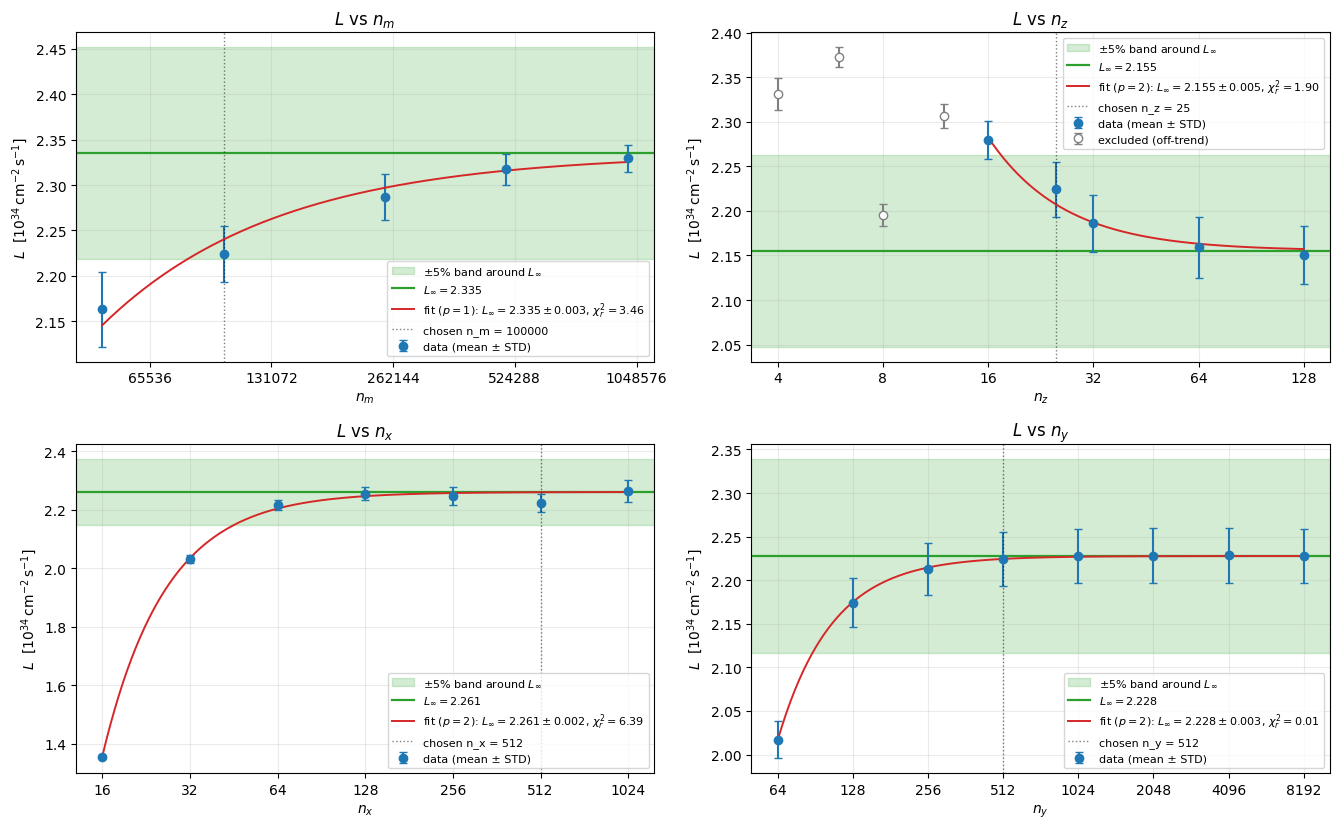

In [11]:
# Convergence scan: increase each grid parameter (n_m, n_z, n_x, n_y) one at a
# time and find the region where the luminosity L stops changing. Each panel fits
# L = L_inf - C/n^p and shades a +/-5% band around the fitted L_inf. Points that
# sit off the asymptotic trend (low-n_z under-sampling) are dropped from the fit
# and shown as open grey markers.
scan = [
    ('n_m', g_nm, 1, NOM_NM, r'$n_m$', set(),         'lower right'),
    ('n_z', g_nz, 2, NOM_NZ, r'$n_z$', {4, 6, 8, 12}, 'upper right'),
    ('n_x', g_nx, 2, NOM_NX, r'$n_x$', set(),         'lower right'),
    ('n_y', g_ny, 2, NOM_NY, r'$n_y$', set(),         'lower right'),
]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.4))
for (col, g_all, p, nom, xlbl, drop, loc), ax in zip(scan, axes.flatten()):
    g      = g_all[~g_all[col].isin(drop)].reset_index(drop=True)
    g_drop = g_all[g_all[col].isin(drop)]

    # fit L_inf - C/n^p; the +/-5% band is centred on the fitted L_inf
    fit  = fit_Linf_fixed_p(g, col, p)
    Linf = fit['L_inf'] / L_UNIT
    sig  = fit['sigma_L_inf'] / L_UNIT
    ax.axhspan(Linf * 0.95, Linf * 1.05, color='C2', alpha=0.20,
               label=r'$\pm 5\%$ band around $L_\infty$')
    ax.axhline(Linf, color='C2', lw=1.6, label=fr'$L_\infty = {Linf:.3f}$')

    # data (filled) and off-trend points (open)
    n  = g[col].values
    ax.errorbar(n, g['mean_L'].values / L_UNIT, yerr=g['std_L'].values / L_UNIT,
                fmt='o', color='C0', ecolor='C0', capsize=3, markersize=6,
                label='data (mean ± STD)')
    if len(g_drop):
        ax.errorbar(g_drop[col].values, g_drop['mean_L'].values / L_UNIT,
                    yerr=g_drop['std_L'].values / L_UNIT, fmt='o', mfc='white',
                    mec='grey', color='grey', capsize=3, markersize=6,
                    label='excluded (off-trend)')

    # fit curve
    nn   = np.geomspace(n.min(), n.max(), 250)
    Lfit = (fit['L_inf'] - fit['C'] / nn**p) / L_UNIT
    ax.plot(nn, Lfit, '-', color='C3', lw=1.4,
            label=fr"fit ($p={p}$): $L_\infty={Linf:.3f}\pm{sig:.3f}$, "
                  fr"$\chi^2_r={fit['chi2_red']:.2f}$")

    ax.axvline(nom, color='k', ls=':', lw=1, alpha=0.5,
               label=f'chosen {col} = {nom}')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{int(v)}'))
    ax.set_xlabel(xlbl)
    ax.set_ylabel(r'$L$  [$10^{34}\,$cm$^{-2}\,$s$^{-1}$]')
    ax.set_title(fr'$L$ vs {xlbl}')
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(loc=loc, fontsize=8)

plt.tight_layout()
save_fig(fig, 'convergence_scan')
plt.show()


## Figure 2 — Refined convergence scan

Move to the smallest `n` inside each converged region, then re-sweep each parameter on a finer grid to confirm `L` is flat there. Same fit and ±5% band as Figure 1.

Saved: plots/convergence_scan_refined.pdf, plots/convergence_scan_refined.png


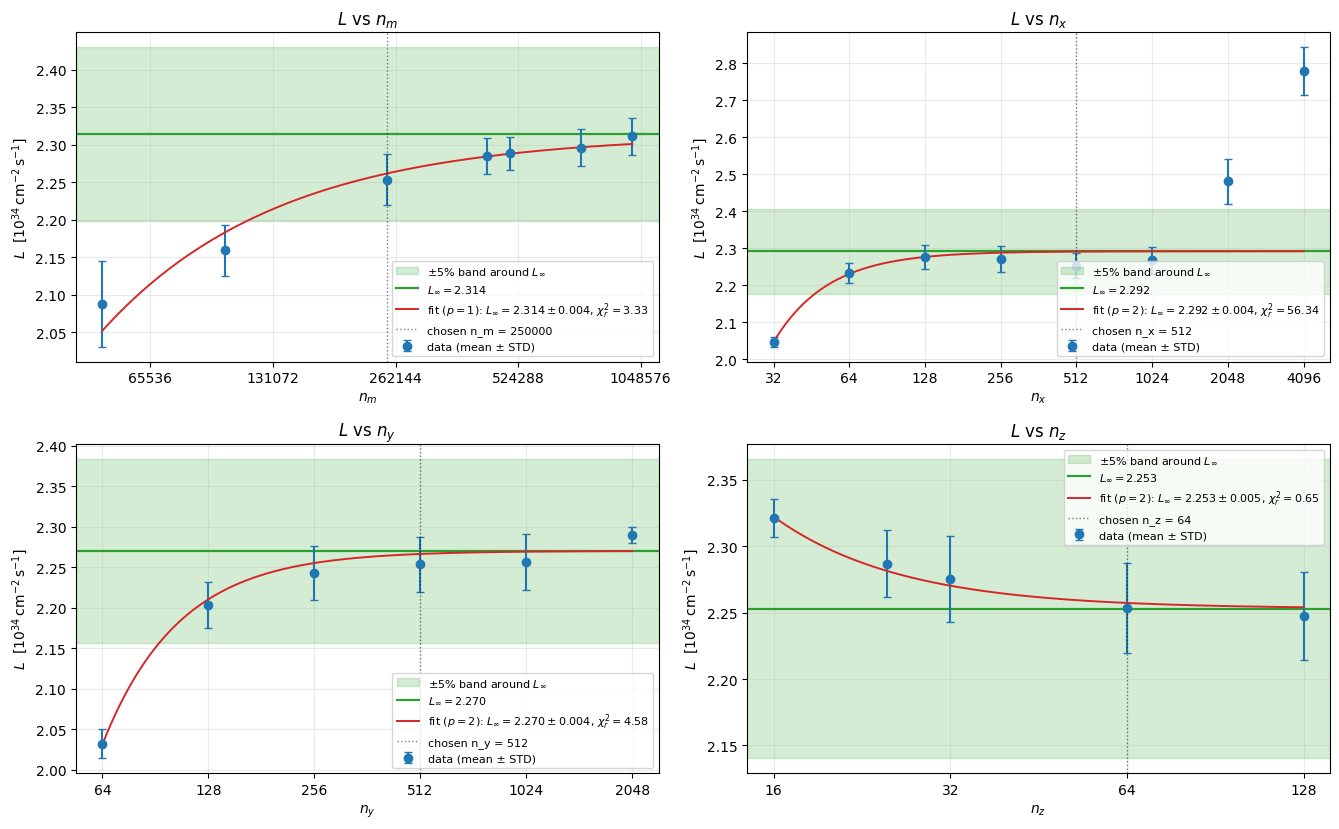

In [12]:
# Refined scan: starting from the smallest n inside each converged region, re-sweep
# every grid parameter on a finer set of points to confirm L is flat there. Same
# estimator as Figure 1: fit L = L_inf - C/n^p with a +/-5% band on the fitted L_inf.
scan_refined = [
    ('n_m', g_nm_2, 1, P2_NM, r'$n_m$', 'lower right'),
    ('n_x', g_nx_2, 2, P2_NX, r'$n_x$', 'lower right'),
    ('n_y', g_ny_2, 2, P2_NY, r'$n_y$', 'lower right'),
    ('n_z', g_nz_2, 2, P2_NZ, r'$n_z$', 'upper right'),
]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.4))
for (col, g, p, nom, xlbl, loc), ax in zip(scan_refined, axes.flatten()):
    ax.set_xlabel(xlbl)
    ax.set_ylabel(r'$L$  [$10^{34}\,$cm$^{-2}\,$s$^{-1}$]')
    ax.set_title(fr'$L$ vs {xlbl}')
    ax.grid(True, which='both', alpha=0.25)
    if len(g) < 2:
        ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                transform=ax.transAxes, color='grey')
        continue

    fit = fit_Linf_fixed_p(g, col, p) if len(g) >= 3 else None
    if fit is not None and np.isfinite(fit['L_inf']):
        Linf = fit['L_inf'] / L_UNIT
        sig  = fit['sigma_L_inf'] / L_UNIT
    else:
        Linf, sig = g['mean_L'].iloc[-1] / L_UNIT, float('nan')

    ax.axhspan(Linf * 0.95, Linf * 1.05, color='C2', alpha=0.20,
               label=r'$\pm 5\%$ band around $L_\infty$')
    ax.axhline(Linf, color='C2', lw=1.6, label=fr'$L_\infty = {Linf:.3f}$')

    n = g[col].values
    ax.errorbar(n, g['mean_L'].values / L_UNIT, yerr=g['std_L'].values / L_UNIT,
                fmt='o', color='C0', ecolor='C0', capsize=3, markersize=6,
                label='data (mean ± STD)')

    if fit is not None and np.isfinite(fit['L_inf']):
        nn   = np.geomspace(n.min(), n.max(), 250)
        Lfit = (fit['L_inf'] - fit['C'] / nn**p) / L_UNIT
        ax.plot(nn, Lfit, '-', color='C3', lw=1.4,
                label=fr"fit ($p={p}$): $L_\infty={Linf:.3f}\pm{sig:.3f}$, "
                      fr"$\chi^2_r={fit['chi2_red']:.2f}$")

    ax.axvline(nom, color='k', ls=':', lw=1, alpha=0.5,
               label=f'chosen {col} = {nom}')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{int(v)}'))
    ax.legend(loc=loc, fontsize=8)

plt.tight_layout()
save_fig(fig, 'convergence_scan_refined')
plt.show()


## Figure 3 — Macroparticle calibration: `n_m^req` vs `ε_y`

Left: `L` vs `n_m` for a range of vertical emittances, with the fitted `n_m^req` (the `n_m` at which `L` first reaches the ±5% band). Right: the resulting `n_m^req/(n_x n_y n_z)` vs the disruption parameter `D_y(ε_y)`, fitted to a power law.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved: plots/L_vs_nm.pdf, plots/L_vs_nm.png


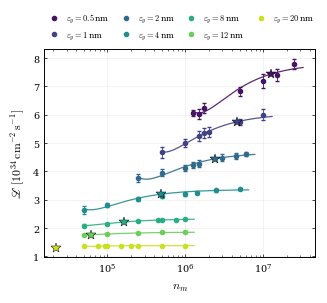

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved: plots/nm_req_tuning.pdf, plots/nm_req_tuning.png


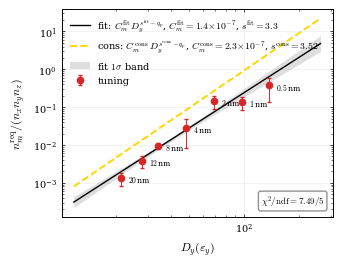


  fitted s^fit = 3.330 ± 0.250     C_m^fit = 1.404e-07 ± 1.31e-07     χ²/ndf = 7.49/5   p = 0.187


In [13]:
# Macroparticle calibration: the required macroparticle count n_m^req as a
# function of vertical emittance e_y.
#   Left  panel: L vs n_m for each e_y, with the fitted n_m^req (the n_m at
#                which L reaches the +/-5% band, marked with a star).
#   Right panel: n_m^req/(n_x n_y n_z) vs the disruption parameter D_y(e_y),
#                fitted to the power law C_m * D_y^(s-q).

from pathlib import Path
import matplotlib.ticker as mticker

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

prl_style_local = {
    'font.family':      'serif',
    'font.size':        8,
    'axes.labelsize':   8.5,
    'axes.titlesize':   8,
    'legend.fontsize':  6.5,
    'xtick.labelsize':  7,
    'ytick.labelsize':  7,
    'axes.linewidth':   0.7,
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linewidth':   0.4,
    'lines.linewidth':  1.0,
    'lines.markersize': 3.2,
    'text.usetex':      False,
    'mathtext.fontset': 'cm',
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
}

# ────────────────────── Figure 1: L vs n_m ──────────────────────────────
with plt.rc_context(prl_style_local):
    fig, ax = plt.subplots(figsize=(3.5, 2.7))
    colors = plt.cm.viridis(np.linspace(0.05, 0.92, len(EPS_CASES_DELTA)))

    for (label, ey_csv, ny_a), color in zip(EPS_CASES_DELTA, colors):
        holds = {'n_x': 512, 'n_y': ny_a, 'n_z': 64}
        g_all = aggregate_at_eps(df, 'n_m', ey_csv, holds)
        # Points outside the asymptotic range of their own sweep are dropped
        # outright: excluded from the fit AND not drawn. One global rule,
        # L >= L_FRAC_NM * L_max — see `nm_asymptotic_points`.
        g_used = nm_asymptotic_points(g_all)
        if len(g_used) < 2:
            continue

        eps_lbl = label.replace(r'$\varepsilon_y = ', '').replace('$', '').replace(' nm', '')

        # fit — reuse the calibration cell's stored fit on its asymptotic window,
        # so the drawn curve is literally the fit that produced n_m^req.
        aw_nm = NM_WINDOW.get(ey_csv)
        if aw_nm is not None:
            k_sel  = K_SEL_NM.get(ey_csv)
            fit    = aw_nm['best']['fit']
            g_used = aw_nm['window']
            if fit is not None:
                beta = fit['beta']
                n_m_req = n_req_kterm_signed(beta, TOL_NM, P_NM, k_sel, N_SCALE)
                top = max(g_used['n_m'].max(),
                          n_m_req if np.isfinite(n_m_req) else 0) * 1.3
                nn_used = np.geomspace(g_used['n_m'].min(), top, 250)
                Lfit = (beta[0] - sum(beta[i] / (nn_used / N_SCALE)**(P_NM*i)
                                      for i in range(1, k_sel+1))) / L_UNIT
                ok = Lfit > 0
                ax.plot(nn_used[ok], Lfit[ok], '-', color=color,
                        lw=0.9, alpha=0.9, zorder=4)
                if np.isfinite(n_m_req) and n_m_req > 0:
                    L_at_req = beta[0] * (1.0 - TOL_NM) / L_UNIT
                    ax.plot([n_m_req], [L_at_req], '*', color=color, ms=7,
                            markeredgecolor='black', markeredgewidth=0.35,
                            zorder=10)

        # used data points (small)
        ax.errorbar(g_used['n_m'].values,
                    g_used['mean_L'].values / L_UNIT,
                    yerr=g_used['std_L'].values / L_UNIT,
                    fmt='o', color=color, ecolor=color,
                    capsize=1.2, elinewidth=0.6, lw=0, ms=3.0,
                    zorder=5)

    ax.set_xscale('log', base=10)
    ax.set_xlabel(r'$n_m$')
    ax.set_ylabel(r'$\mathscr{L}\ [10^{34}\,\mathrm{cm^{-2}\,s^{-1}}]$')
    ax.tick_params(direction='in', length=2.5, width=0.5, top=True, right=True)
    ax.tick_params(which='minor', direction='in', length=1.5, width=0.4,
                   top=True, right=True)
    # compact in-axes legend with ε_y values only
    handles, labels = [], []
    for (label, ey_csv, ny_a), color in zip(EPS_CASES_DELTA, colors):
        eps_lbl = label.replace(r'$\varepsilon_y = ', '').replace('$', '').replace(' nm', '')
        handles.append(plt.Line2D([0], [0], marker='o', color=color, lw=0, markersize=3))
        labels.append(fr'$\varepsilon_y={eps_lbl}\,$nm')
    # legend above the axes so it cannot overlap the curves
    ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.02),
              frameon=False, fontsize=6.0, ncol=4, columnspacing=1.0,
              handletextpad=0.4, borderaxespad=0.0)
    save_fig(fig, 'L_vs_nm')
    plt.show()


# ────────────────── Figure 2: n_m^req / (n_xyz) vs D_y ─────────────────
with plt.rc_context(prl_style_local):
    fig, ax = plt.subplots(figsize=(3.5, 2.7))

    ok = cal_df[cal_df['n_m_req_per_nxyz'].notna()].copy()
    if len(ok) >= 2:
        logD  = np.log(ok['D_y'].values)
        logNm = np.log(ok['n_m_req_per_nxyz'].values)
        sig_log = ok['sigma_log_nm'].values.astype(float)
        finite  = np.isfinite(sig_log) & (sig_log > 0)
        sig_fill = float(np.median(sig_log[finite])) if finite.any() else 0.1
        sig_log  = np.where(finite, sig_log, sig_fill)
        sig_log  = np.maximum(sig_log, 1e-3)
        w  = 1.0 / sig_log**2
        sw, sxw, syw = w.sum(), (w * logD).sum(), (w * logNm).sum()
        sxxw, sxyw   = (w * logD**2).sum(), (w * logD * logNm).sum()
        det          = sw * sxxw - sxw**2
        intercept    = (sxxw * syw - sxw * sxyw) / det
        slope        = (sw   * sxyw - sxw * syw)   / det
        var_slope    = sw   / det
        # The sweeps measure the slope b = s - q directly; s is recovered with
        # the pinch exponent q = Q_PINCH.
        s_param      = slope + Q_PINCH
        sigma_s      = float(np.sqrt(var_slope))
        var_int      = sxxw / det
        cov_int_slope = -sxw / det               # covariance term for band
        sigma_int    = float(np.sqrt(var_int))
        C_m          = float(np.exp(intercept))
        sigma_C_m    = float(C_m * sigma_int)   # δC_m = C_m · δ(log C_m)
        # ── χ²/ndf and p-value from the weighted LS residuals ──
        pred_log     = intercept + slope * logD
        resid_log    = logNm - pred_log
        chi2_val     = float(((resid_log / sig_log)**2).sum())
        ndf_val      = len(ok) - 2
        from scipy.stats import chi2 as _chi2_dist
        p_value      = float(1.0 - _chi2_dist.cdf(chi2_val, ndf_val)) if ndf_val > 0 else float('nan')

        # data
        yerr_lin = ok['n_m_req_per_nxyz'].values * sig_log
        ax.errorbar(ok['D_y'].values, ok['n_m_req_per_nxyz'].values,
                    yerr=yerr_lin, fmt='o', ms=4.5, color='C3',
                    capsize=1.5, ecolor='C3', elinewidth=0.7, lw=0,
                    zorder=5, label='tuning')

        # power-law line — fitted
        dx = np.geomspace(ok['D_y'].min() * 0.55, ok['D_y'].max() * 1.9, 80)
        # Standard form (1 digit + 1 decimal × power of 10) for C_m display
        import math as _math
        def _stdform(x):
            if not (x and _math.isfinite(x)): return ('0', 0)
            e = int(_math.floor(_math.log10(abs(x))))
            m = x / 10**e
            return (f'{m:.1f}', e)
        Cm_mant, Cm_exp = _stdform(C_m)
        s_disp = round(s_param, 1)         # 1 decimal on s
        ax.plot(dx, C_m * dx**(s_param - Q_PINCH), '-', color='k', lw=1.0, zorder=4,
                label=(fr'fit: $C_m^{{\mathrm{{fit}}}}\,D_y^{{s^{{\mathrm{{fit}}}}-q_p}}$, '
                       fr'$C_m^{{\mathrm{{fit}}}}={Cm_mant}\!\times\!10^{{{Cm_exp}}}$, '
                       fr'$s^{{\mathrm{{fit}}}}={s_disp}$'))
        # ── conservative locus (CANONICAL) ──────────────────────────────
        # The normalisation reproduces the n_m values used in the eps_y = 1, 2, 4 nm
        # scans. This is the line the n_y study (Figures 5/6) uses to set n_m.
        # b_cons = 3.3 is the slope of the conservative locus and the quantity the
        # runs used; s_cons = b_cons + q_p.
        # Frozen conservative-locus constants, defined once in constants.py and
        # never refit here: 2.305e-7 and the effective exponent b_cons = 3.300.
        from constants import C_M_CONS, NM_EXPONENT_CONS as B_CONS
        assert (C_M_CONS, B_CONS) == (2.305e-07, 3.3)
        S_CONS = B_CONS + Q_PINCH
        C_M_NM,   S_NM   = C_M_CONS, S_CONS      # n_y study reads these
        ax.plot(dx, C_M_CONS * dx**(S_CONS - Q_PINCH), '--', color='gold', lw=1.4, zorder=4,
                label=(fr'cons: $C_m^{{\mathrm{{cons}}}}\,D_y^{{s^{{\mathrm{{cons}}}}-q_p}}$, '
                       fr'$C_m^{{\mathrm{{cons}}}}={_stdform(C_M_CONS)[0]}\!\times\!10^{{{_stdform(C_M_CONS)[1]}}}$, '
                       fr'$s^{{\mathrm{{cons}}}}={S_CONS:.2f}$'))

        # ── 1σ uncertainty band on the fit line (joint cov of intercept+slope) ──
        logdx = np.log(dx)
        # Var[log y(x)] = Var(int) + 2 x Cov(int,slope) + x² Var(slope)
        var_pred_log = var_int + 2.0 * logdx * cov_int_slope + (logdx**2) * var_slope
        sigma_pred_log = np.sqrt(np.maximum(var_pred_log, 0.0))
        y_centre = C_m * dx**(s_param - Q_PINCH)
        y_upper  = y_centre * np.exp(sigma_pred_log)
        y_lower  = y_centre * np.exp(-sigma_pred_log)
        ax.fill_between(dx, y_lower, y_upper, color='k', alpha=0.13, lw=0,
                        zorder=3, label=fr'fit $1\sigma$ band')

        # ── annotate χ²/ndf + p-value in the bottom-right corner ──
        # One chi2 only: the goodness of fit of the drawn power law.
        ax.text(0.97, 0.04,
                fr'$\chi^2/\mathrm{{ndf}} = {chi2_val:.2f}/{ndf_val}$',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=6.5, linespacing=1.2,
                bbox=dict(facecolor='white', alpha=0.85,
                          edgecolor='0.5', boxstyle='round,pad=0.25'))

        # per-point ε_y annotation
        for _, r in ok.iterrows():
            ax.annotate(fr"${r['eps_y_nm']:g}\,$nm",
                        (r['D_y'], r['n_m_req_per_nxyz']),
                        textcoords='offset points', xytext=(5, -3),
                        fontsize=5.6)

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(r'$D_y(\varepsilon_y)$')
        ax.set_ylabel(r'$n_m^{\mathrm{req}}/(n_x n_y n_z)$')
        ax.tick_params(direction='in', length=2.5, width=0.5, top=True, right=True)
        ax.tick_params(which='minor', direction='in', length=1.5, width=0.4,
                       top=True, right=True)
        ax.legend(loc='upper left', frameon=False, fontsize=7)

        save_fig(fig, 'nm_req_tuning')
        plt.show()
        print(f'\n  fitted s^fit = {s_param:.3f} ± {sigma_s:.3f}     '
              f'C_m^fit = {C_m:.3e} ± {sigma_C_m:.2e}     '
              f'χ²/ndf = {chi2_val:.2f}/{ndf_val}   p = {p_value:.3f}')
    else:
        print('not enough calibration points for the s plot')

## Figure 4 — `L` vs `n_x` and `n_z` at three emittances

The 6-panel test: `L` vs `n_x` and `n_z` at ε_y = 2, 8 and 20 nm. Both sweeps use the same Richardson model as the `n_m` fits, `L = L∞ − Σᵢ Cᵢ/(n/n₀)^(p·i)`, with the leading order `p` set per sweep variable, the same weighted least squares and the same ±5% crossing `n^req`.

=== Shared leading order for the spatial sweeps (P_POLICY='derived') ===
  p(n_x) = 2.00   from the scan design:  alpha = 2:-0.001, 8:-0.667, 20:-1.264
  p(n_x) = 1.69 ± 0.05   [prior 2, pull -6.5σ]   k=1 total χ²/ndf = 35.7/10  <- NOT identifiable: k=1 mis-specified (χ²_r=3.6)
  adopted p(n_x) = 2.00  (derived from the scan design)
  p(n_z) = 2.00   from the scan design:  alpha = 2:-0.001, 8:-0.366, 20:-1.132
  p(n_z) = 3.36 ± 0.59   [prior 2, pull +2.3σ]   k=1 total χ²/ndf = 24.8/5  <- NOT identifiable: k=1 mis-specified (χ²_r=5.0)
  adopted p(n_z) = 2.00  (derived from the scan design)

n^req criterion vs L_vs_nm: max relative difference over the 1 n_m fits = 1.45e-11


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved: plots/L_vs_n_by_emittance_6panel.pdf, plots/L_vs_n_by_emittance_6panel.png


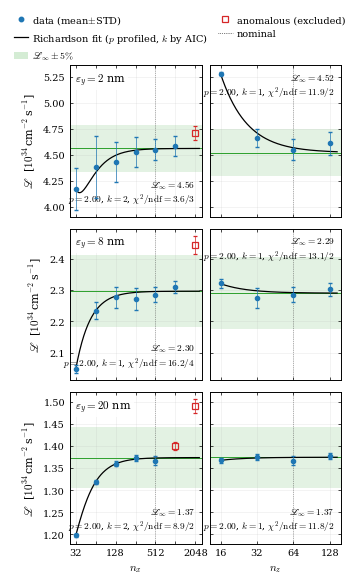


Every sampled grid point meets the conservative n_m requirement.
=== 6-panel fits: Richardson, p profiled per sweep variable (n_x:2.00, n_z:2.00), k by AIC, ±5% crossing ===
Anchor: n_x = 512, n_z = 64, n_y = 512; the swept parameter replaces its anchor value. n_m is NOT fixed — it is chosen per point as the smallest available run at or above the conservative locus C_m·D_y^(s−q)·n_x·n_y·n_z (C_m = 2.305e-07, s = 3.515, q = 0.215).
 eps_y_nm sweep  n_fit  n_anom  L_inf  n_req   p  k k_admis  chi2_r  dof      fit_mode
      2.0   n_x      6       1 4.5606   64.8 2.0  2     1,2   1.185    3 unconstrained
      2.0   n_z      4       0 4.5195   29.4 2.0  1       1   5.926    2 unconstrained
      8.0   n_x      6       1 2.2961   47.1 2.0  1     1,2   4.052    4 unconstrained
      8.0   n_z      4       0 2.2896    8.3 2.0  1       1   6.554    2 unconstrained
     20.0   n_x      5       2 1.3739   56.6 2.0  2     1,2   4.445    2 unconstrained
     20.0   n_z      4       0 1.3748    5

In [14]:
# Vertical-resolution calibration: how fine the transverse grid must be vs e_y.
#   Figure A: L vs (n_x, n_z) for three emittances, each fitted with the same
#             Richardson machinery as the L vs n_m calibration, but with its own
#             leading order p profiled per sweep variable (see below).

from pathlib import Path
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

# SINGLE-COLUMN FIGURE. The point sizes below are the sizes that appear ON THE
# PAGE, which only holds if the figure is included at its natural width — i.e.
# \includegraphics{...} with no scaling, or width=\columnwidth on a figure that
# is already \columnwidth (3.375 in for PRL/REVTeX). Do not widen the figure without
# re-scaling these numbers, and do not set width= to anything but \columnwidth.
prl_style = {
    'font.family':      'serif',
    'font.size':        8,
    'axes.labelsize':   8,
    'axes.titlesize':   8,
    'legend.fontsize':  7,
    'xtick.labelsize':  7,
    'ytick.labelsize':  7,
    'axes.linewidth':   0.7,
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linewidth':   0.4,
    'lines.linewidth':  1.0,
    'lines.markersize': 3.2,
    'text.usetex':      False,
    'mathtext.fontset': 'cm',
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
}

EPS_CASES_PRL = [
    ('2',   0.002,   512),
    ('8',   0.008,   512),
    ('20',  0.020,   512),
]

# n_m IS NOT HELD FIXED ON THESE PANELS.
# At fixed n_m the macroparticles per cell m = n_m/(n_x n_y n_z) fall as 1/n
# along a spatial sweep, so the shot-noise term GROWS with the swept variable
# and contaminates the very convergence the panel is measuring (it is also what
# forces alpha = -1 and hence p = P_CIC, see `derive_p`). Instead every point
# must sit on or above the conservative locus,
#     n_m >= C_m * D_y(eps_y)^(s-q) * n_x*n_y*n_z,     C_m = C_M_CONS, s = S_CONS
# and among the qualifying runs the SMALLEST n_m is used — closest to the
# requirement from above, so macroparticles per cell are held as near constant
# along the sweep as the available runs allow.
SIXP_NM_TOL   = 0.98      # tolerate the 3-s.f. rounding of the submitted n_m
SIXP_MIN_SEED = 6

def sixpanel_nm_req(eps_csv, n_x, n_y, n_z):
    """Conservative-locus macroparticle requirement for one grid point."""
    return C_M_CONS * D_y_full(eps_csv * 1e3)**(S_CONS - Q_PINCH) * n_x * n_y * n_z

# Only n_x and n_z are shown (the n_m column lives in its own figure,
# `L_vs_nm`, which this panel now shares its fit model with).
# (col_name, x-label, xlim, tick-list, tick-labels)
# The n_x sweep is restricted to the powers of two 2^5…2^11. The odd
# intermediate n_x (384, 768, sampled only at eps_y = 20 nm) and n_x = 4096 are
# dropped entirely — from the figure and from the fit.
N_X_ALLOWED = [2**k for k in range(5, 12)]      # 32 … 2048
# n_z likewise: the panel shows 16…128. The lower n_z (4, 6, 8, 12) are
# under-sampled longitudinally and off the convergence trend, and the odd
# intermediate values (25, 96) were run for other studies.
N_Z_ALLOWED = [16, 32, 64, 128]

# Points shown but held OUT of the fit. At the top of the n_x range L turns
# back UP and away from the plateau every other point has settled onto, so
# these cannot be described by a monotone Richardson tail; folding them in
# drags L_inf upward and inflates chi2_r. Keyed by (eps_y in CSV units, sweep).
ANOMALOUS = {
    (0.002, 'n_x'): (2048,),
    (0.008, 'n_x'): (2048,),
    (0.020, 'n_x'): (1024, 2048),
}

# xlim padded ~25% beyond first/last data value on the log scale.
# At the single-column width (§ figure style) seven labelled decades of n_x do
# not fit on the axis — "512 1024 2048" runs together. Tick every point, but
# LABEL every other one; the unlabelled ticks still mark the sampled values.
SWEEPS_PRL = [
    ('n_x', r'$n_x$', (26, 2560),
        [32, 64, 128, 256, 512, 1024, 2048],
        ['32', '', '128', '', '512', '', '2048']),
    ('n_z', r'$n_z$', (13, 160),
        [16, 32, 64, 128],
        ['16', '32', '64', '128']),
]


# =============================================================================
# 6-panel theory test (rows = ε_y, cols = {n_x, n_z})
#
# The fit MACHINERY is identical to `L_vs_nm` / `nm_req_tuning` (the
# calibration cell above) — same solver, same k rule, same n^req criterion, same
# error model. Only the leading order p differs, and it differs because it is
# measured per sweep family rather than assumed. For every panel:
#
#   * model      : Richardson expansion L(n) = L_inf − Σ_{i=1..k} C_i/(n/n_0)^(p·i).
#   * p          : ONE leading order per sweep VARIABLE, shared across the three
#                  ε_y and profiled by `profile_p` — the same policy the n_m and
#                  n_y families use. n_x/n_z are spatial sweeps whose leading
#                  error is CIC deposition, O(h²)=O(1/n²), not shot noise, so
#                  the prior here is p=2 and the profile tests it.
#   * k          : chosen per panel by `select_k_aic` — the same AIC rule the
#                  n_m and n_y fits use. Candidates are k = 1…min(3, N−2), every
#                  order leaving at least one degree of freedom. The selected k
#                  and the admissible set are reported per panel.
#   * solver     : the same hybrid weighted LS as `fit_kterm_local` — try
#                  unconstrained, fall back to C_i ≥ 0 when the series has no
#                  ±5% crossing — reusing its `_fit_kterm_core` verbatim.
#   * n^req      : the same ±TOLERANCE_PCT crossing as `n_m_req_kterm`, written
#                  on |L(n) − L_inf| so it is also defined when L converges from
#                  above (ε_y = 0.5 nm; see `n_req_kterm_signed`). Reported in
#                  the table below; not marked on the panels.
#   * n_0        : per-sweep numerical rescale, the geometric mean of the
#                  sampled n. This plays exactly the role N_SCALE=1e6 plays for
#                  n_m — it keeps the design-matrix columns O(1) so the solve
#                  stays conditioned. n_x/n_z span 32–2048 and 16–128, so the
#                  n_m value of 1e6 would drive 1/(n/n_0)³ to ~1e13.
# =============================================================================

n_scale_for = n_scale_geom     # single definition, in the calibration cell


SIXP_DROPPED = {}          # (eps_csv, sweep) -> [(n, best n_m available, need)]

def sixpanel_points(eps_csv, ny_a, sw, apply_anomalous=True):
    """Point set for one panel, with n_m selected on the conservative locus.

    For each value of the swept variable, keep the runs whose n_m meets the
    requirement (>= SIXP_NM_TOL x target) and take the smallest of them. Sweep
    values with no qualifying run are dropped and recorded in SIXP_DROPPED, so
    a gap in a panel is always explained rather than silent.

    Reads `df_all`, not `df`: the global n_m >= 5e4 floor is a n_m-sweep device
    and has no place here, where n_m is set by the locus.
    """
    anchor = {'n_x': 512, 'n_y': ny_a, 'n_z': 64}
    holds  = {k: v for k, v in anchor.items() if k != sw}
    sel = df_all[
        (df_all['emitt_y'] == eps_csv) & (df_all['emitt_x'] == EPS_X_CAL) &
        (df_all['beta_x'] == BETA_X)   & (df_all['beta_y'] == BETA_Y) &
        (df_all['sigma_z'] == SIGMA_Z) & (df_all['offset_y'] == OFFSET_Y) &
        (df_all['particles'] == PARTICLES) &
        (df_all['integration_method'] == NOM_IM) & (df_all['n_t'] == NOM_NT) &
        (df_all['cut_x'] == NOM_CX) & (df_all['cut_y'] == NOM_CY) &
        (df_all['cut_z'] == NOM_CZ) & df_all['lumi_ee'].notna() &
        df_all['seed'].isin(CANONICAL_SEEDS)].copy()
    for col, val in holds.items():
        sel = sel[sel[col] == val]
    allowed = {'n_x': N_X_ALLOWED, 'n_z': N_Z_ALLOWED}.get(sw)
    if allowed is not None:
        sel = sel[sel[sw].isin(allowed)]
    sel = (sel.sort_values('source_priority')
              .drop_duplicates(subset=[sw, 'n_m', 'seed'], keep='first'))
    g = (sel.groupby([sw, 'n_m'])
            .agg(n_seeds=('seed', 'nunique'), mean_L=('lumi_ee', 'mean'),
                 std_L=('lumi_ee', 'std')).reset_index())
    g = g[g['n_seeds'] >= SIXP_MIN_SEED]
    if not len(g):
        SIXP_DROPPED[(eps_csv, sw)] = []
        return g.assign(sem_L=[], nm_req_cons=[])

    n_x = g[sw].values.astype(float) if sw == 'n_x' else np.full(len(g), 512.0)
    n_z = g[sw].values.astype(float) if sw == 'n_z' else np.full(len(g), 64.0)
    g['nm_req_cons'] = sixpanel_nm_req(eps_csv, n_x, float(ny_a), n_z)

    ok = g[g['n_m'] >= g['nm_req_cons'] * SIXP_NM_TOL]
    dropped = []
    for v in sorted(set(g[sw]) - set(ok[sw])):
        sub = g[g[sw] == v]
        dropped.append((v, int(sub['n_m'].max()), float(sub['nm_req_cons'].iloc[0])))
    SIXP_DROPPED[(eps_csv, sw)] = dropped
    if not len(ok):
        return ok.assign(sem_L=[])

    keep = ok.loc[ok.groupby(sw)['n_m'].idxmin()].sort_values(sw).reset_index(drop=True)
    keep['sem_L'] = keep['std_L'] / np.sqrt(keep['n_seeds'])
    if apply_anomalous:
        keep = keep[~keep[sw].isin(ANOMALOUS.get((eps_csv, sw), ()))]
    return keep.reset_index(drop=True)


def sixpanel_set(eps_csv, ny_a, sw):
    """Fitted point set — the locus selection with ANOMALOUS removed."""
    return sixpanel_points(eps_csv, ny_a, sw, apply_anomalous=True)


# ── One shared leading order per spatial sweep variable (METHODS §3) ──────────
print(f'=== Shared leading order for the spatial sweeps (P_POLICY={P_POLICY!r}) ===')
PROF_SPATIAL, P_SPATIAL, SIG_P_SPATIAL = {}, {}, {}
for _sw, _xlbl, _xlim, _tloc, _tlab in SWEEPS_PRL:
    _sets = {float(el): sixpanel_set(ec, na, _sw)
             for el, ec, na in EPS_CASES_PRL}
    _sets = {e: g for e, g in _sets.items() if len(g) >= 4}
    if not _sets:
        P_SPATIAL[_sw], SIG_P_SPATIAL[_sw] = P_CIC, 0.0
        continue
    _anch = {float(el): {'n_x': 512, 'n_y': na, 'n_z': 64, 'n_m': 250000}
             for el, ec, na in EPS_CASES_PRL if float(el) in _sets}
    _der  = derive_p(_sets, _sw, _anch, label=_sw)      # derive first, so the
    PROF_SPATIAL[_sw] = profile_p(_sets, _sw, label=_sw)  # profile can report
    PROF_SPATIAL[_sw]['p_derived'] = _der['p']            # its pull against it
    P_SPATIAL[_sw]     = p_in_use(PROF_SPATIAL[_sw], _sw)
    SIG_P_SPATIAL[_sw] = sigma_p_in_use(PROF_SPATIAL[_sw], _sw)
    print(f'  adopted p({_sw}) = {P_SPATIAL[_sw]:.2f}  '
          f'({"profiled" if SIG_P_SPATIAL[_sw] > 0 else "derived from the scan design"})')
print()


# ── Consistency check: on the n_m fits (all Cᵢ > 0, L rising to L_inf) the
#    generalised crossing must reproduce `n_m_req_kterm` — i.e. this figure and
#    L_vs_nm apply literally the same convergence criterion.
_check = []
for _lbl, _ey, _nya in EPS_CASES_DELTA:
    _k = K_SEL_NM.get(_ey)
    if not _k:
        continue
    _g = aggregate_at_eps(df, 'n_m', _ey, {'n_x': 512, 'n_y': _nya, 'n_z': 64})
    _g = nm_asymptotic_points(_g)
    _f = fit_kterm_signed(_g, 'n_m', P_NM, _k, N_SCALE)
    if _f is None:
        continue
    _a = n_m_req_kterm(_f['beta'], TOL_NM, P_NM, _k)
    _b = n_req_kterm_signed(_f['beta'], TOL_NM, P_NM, _k, N_SCALE)
    if np.isfinite(_a) and np.isfinite(_b):
        _check.append(abs(_b - _a) / _a)
print(f'n^req criterion vs L_vs_nm: max relative difference over the '
      f'{len(_check)} n_m fits = {max(_check):.2e}' if _check else
      'n^req criterion: no n_m fits to cross-check')

sixpanel_rows, anom_rows = [], []

with plt.rc_context(prl_style):
    fig, axes = plt.subplots(3, 2, figsize=(3.375, 5.8),
                             sharex='col', sharey='row',
                             gridspec_kw=dict(hspace=0.08, wspace=0.06))

    for row, (eps_lbl, eps_csv, ny_a) in enumerate(EPS_CASES_PRL):
        for col, (sw, xlbl, xlim, tloc, tlab) in enumerate(SWEEPS_PRL):
            ax = axes[row, col]
            anchor = {'n_x': 512, 'n_y': ny_a, 'n_z': 64}
            # n_m selected per point on the conservative locus (see above);
            # ANOMALOUS points are kept here so they can still be drawn.
            g = sixpanel_points(eps_csv, ny_a, sw, apply_anomalous=False)
            # An empty or short frame falls through to the 'no data' branch below.

            # Split off the anomalous high-n_x points (see ANOMALOUS above):
            # shown on the plot, held out of the fit.
            anom_n  = ANOMALOUS.get((eps_csv, sw), ())
            is_anom = g[sw].isin(anom_n).values
            g_fit   = g[~is_anom].reset_index(drop=True)
            g_anom  = g[is_anom].reset_index(drop=True)
            for _, ar in g_anom.iterrows():
                anom_rows.append(dict(eps_y_nm=float(eps_lbl), sweep=sw,
                                      n=int(ar[sw]), n_seeds=int(ar['n_seeds']),
                                      L=ar['mean_L'] / L_UNIT,
                                      std=ar['std_L'] / L_UNIT))

            rec = dict(eps_y_nm=float(eps_lbl), sweep=sw,
                       n_fit=len(g_fit), n_anom=len(g_anom),
                       L_inf=float('nan'), n_req=float('nan'),
                       p=float('nan'), k=0, k_admis='-',
                       chi2_r=float('nan'), dof=float('nan'), fit_mode='-')

            if len(g_fit) >= 2:
                n  = g_fit[sw].values
                L  = g_fit['mean_L'].values / L_UNIT
                ye = g_fit['std_L'].values  / L_UNIT
                ax.errorbar(n, L, yerr=ye, fmt='o', color='C0',
                            ecolor='C0', capsize=1.2, elinewidth=0.5,
                            markersize=3.0, lw=0, zorder=5)

                # anomalous points: open red squares, excluded from the fit
                if len(g_anom):
                    ax.errorbar(g_anom[sw].values,
                                g_anom['mean_L'].values / L_UNIT,
                                yerr=g_anom['std_L'].values / L_UNIT,
                                fmt='s', mfc='none', color='C3', ecolor='C3',
                                capsize=1.2, elinewidth=0.5, markersize=4.2,
                                markeredgewidth=0.9, lw=0, zorder=6)

                # ── Richardson fit, order k chosen by AICc (same rule as the
                #    n_m and n_y fits) ──
                if len(g_fit) >= 4:
                    ns  = n_scale_for(n)
                    p_sw = P_SPATIAL[sw]
                    best, table = select_k_aic(g_fit, sw, p_sw, ns)
                    fit = best['fit'] if best is not None else None
                    if fit is not None:
                        k_sel = best['k']
                        beta  = fit['beta']
                        Li    = beta[0] / L_UNIT
                        n_req = n_req_kterm_signed(beta, TOL_NM, p_sw,
                                                   k_sel, ns)

                        def L_of(nv, beta=beta, ns=ns, k_sel=k_sel, p_sw=p_sw):
                            return (beta[0] - sum(beta[i] / (nv / ns)**(p_sw * i)
                                                  for i in range(1, k_sel + 1))) / L_UNIT

                        # ±5% band on the fitted L_inf
                        ax.axhspan(Li * (1 - TOL_NM), Li * (1 + TOL_NM),
                                   color='C2', alpha=0.13, lw=0, zorder=1)
                        ax.axhline(Li, color='C2', lw=0.7, zorder=2)

                        # fit curve, drawn across the full displayed range so
                        # the held-out points can be read against it
                        top = max(g[sw].max(), n.max()) * 1.15
                        nn = np.geomspace(n.min(), top, 250)
                        Lfit = L_of(nn)
                        ok = Lfit > 0
                        ax.plot(nn[ok], Lfit[ok], '-', color='k', lw=0.9, zorder=4)

                        chi2_txt = (fr'$\chi^2/\mathrm{{ndf}}='
                                    fr'{fit["chi2_r"] * fit["dof"]:.1f}/{int(fit["dof"])}$'
                                    if np.isfinite(fit['chi2_r']) else r'exact')
                        # If the fit descends to L_inf the data hug the
                        # bottom-right, so annotate top-right (and vice versa).
                        # Compare the fitted endpoints rather than sign(C_1):
                        # a cubic can descend overall with C_1 > 0.
                        from_above = L_of(n.min()) > L_of(n.max())
                        ax.text(0.95, 0.96 if from_above else 0.06,
                                fr'$\mathscr{{L}}_\infty={Li:.2f}$' + '\n'
                                + fr'$p={p_sw:.2f}$, $k={k_sel}$, ' + chi2_txt,
                                transform=ax.transAxes,
                                ha='right', va='top' if from_above else 'bottom',
                                fontsize=6.8, linespacing=1.1)

                        rec.update(p=round(p_sw, 3), k=k_sel,
                                   k_admis=','.join(str(r['k']) for r in table),
                                   L_inf=round(Li, 4),
                                   n_req=(round(n_req, 1)
                                          if np.isfinite(n_req) else float('nan')),
                                   chi2_r=(round(fit['chi2_r'], 3)
                                           if np.isfinite(fit['chi2_r']) else float('nan')),
                                   dof=int(fit['dof']),
                                   fit_mode=fit.get('fit_mode', '?'))
                ax.axvline(anchor[sw], color='k', ls=':', lw=0.5, alpha=0.55)
            else:
                ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                        ha='center', va='center', color='grey', fontsize=7.5)

            sixpanel_rows.append(rec)

            ax.set_xscale('log', base=10)
            ax.set_xlim(*xlim)
            ax.xaxis.set_major_locator(mticker.FixedLocator(tloc))
            ax.xaxis.set_major_formatter(mticker.FixedFormatter(tlab))
            ax.xaxis.set_minor_locator(mticker.NullLocator())
            ax.tick_params(direction='in', length=2.5, width=0.5,
                           top=True, right=True)
            ax.tick_params(which='minor', direction='in', length=1.5, width=0.4,
                           top=True, right=True)

            if col == 0:
                ax.text(0.04, 0.96, fr'$\varepsilon_y = {eps_lbl}$ nm',
                        transform=ax.transAxes, ha='left', va='top',
                        fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.85,
                                  edgecolor='none', pad=1.5))
                ax.set_ylabel(r'$\mathscr{L}$  [$10^{34}\,$cm$^{-2}\,$s$^{-1}$]')
            if row == 2:
                ax.set_xlabel(xlbl)

    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='C0', lw=0, markersize=3.2,
                   label=r'data (mean$\pm$STD)'),
        plt.Line2D([0], [0], color='k', lw=0.9,
                   label='Richardson fit ($p$ profiled, $k$ by AIC)'),
        mpatches.Patch(facecolor='C2', alpha=0.20,
                       label=fr'$\mathscr{{L}}_\infty \pm {TOLERANCE_PCT:.0f}\%$'),
        plt.Line2D([0], [0], marker='s', mfc='none', color='C3', lw=0,
                   markersize=4.2, markeredgewidth=0.9,
                   label='anomalous (excluded)'),
        plt.Line2D([0], [0], color='k', ls=':', lw=0.5, label='nominal'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=2,
               bbox_to_anchor=(0.5, 1.0), frameon=False,
               handlelength=1.5, columnspacing=1.0, handletextpad=0.4)

    fig.subplots_adjust(left=0.175, right=0.980, top=0.895, bottom=0.070)
    save_fig(fig, 'L_vs_n_by_emittance_6panel', dpi=300)
    plt.show()

# ── Sweep values with no run meeting the conservative n_m requirement ───────
_drop_rows = [dict(eps_y_nm=e * 1e3, sweep=sw, n=int(v), n_m_best=int(best),
                   n_m_required=int(round(need)), shortfall=f'{best / need:.2f}x')
              for (e, sw), lst in SIXP_DROPPED.items() for v, best, need in lst]
if _drop_rows:
    print('\n=== dropped: no run at or above the conservative n_m requirement ===')
    print('These grid points exist but only at too few macroparticles per cell, '
          'so they are excluded from the panels.')
    print(pd.DataFrame(_drop_rows).sort_values(['eps_y_nm', 'sweep', 'n'])
            .to_string(index=False))
else:
    print('\nEvery sampled grid point meets the conservative n_m requirement.')

sixpanel_df = pd.DataFrame(sixpanel_rows)
print('=== 6-panel fits: Richardson, p profiled per sweep variable '
      f'({", ".join(f"{k}:{v:.2f}" for k, v in P_SPATIAL.items())}), '
      f'k by AIC, ±{TOLERANCE_PCT:.0f}% crossing ===')
print(f'Anchor: n_x = 512, n_z = 64, n_y = 512; the swept parameter replaces its '
      f'anchor value. n_m is NOT fixed — it is chosen per point as the smallest '
      f'available run at or above the conservative locus '
      f'C_m·D_y^(s−q)·n_x·n_y·n_z (C_m = {C_M_CONS:g}, s = {S_CONS:.3f}, '
      f'q = {Q_PINCH:.3f}).')
print(sixpanel_df.to_string(index=False))

# ── Converged L vs the held-out anomalous points ─────────────────────────
if anom_rows:
    anom_df = pd.DataFrame(anom_rows)
    anom_df['L_inf'] = [
        float(sixpanel_df[(sixpanel_df.eps_y_nm == r.eps_y_nm) &
                          (sixpanel_df.sweep == r.sweep)]['L_inf'].iloc[0])
        for r in anom_df.itertuples()]
    anom_df['excess_pct'] = 100.0 * (anom_df['L'] - anom_df['L_inf']) / anom_df['L_inf']
    print(f'\n=== Held-out points vs converged L_inf '
          f'[10^34 cm^-2 s^-1] ===')
    print(anom_df.round(4).to_string(index=False))


## Figures 5/6 — Vertical resolution: `n_y^req` vs `D_y`

**Model.** `n_y^req = C_y · D_y^q_n` with `q_n = q_p + 1/4 = 0.4653` (manuscript eq:ny_law), where `q_p = 0.2153` is the first-waist envelope exponent (`constants.py`).

**Held fixed for every run:** `n_x = 512`, `n_z = 64`, `n_t = 6`, `integration_method = 2` (FFT), `cut_x/cut_y/cut_z = 20/20/3.5`, `ε_x = 0.9 µm·µrad`, `β_x/β_y = 12/0.12 mm`, `σ_z = 100 µm`, `offset_y = 0`, `particles = 0.624×10¹⁰`, 15 canonical seeds.

**Scanned:** `n_y`. At each rung `n_m` is set from the conservative macroparticle locus `C_m · D_y^(s−q_p) · n_x · n_y · n_z` (`C_m = 2.305×10⁻⁷`, `s − q_p = 3.3`), subject to a floor of `5×10⁴`; the selection is in the next cell.

**Rung selection.** At ε_y = 8–20 nm several rungs come from runs above the locus target rather than on it, so macroparticles per cell are not held fixed along those sweeps (the fit cell below prints the resulting α); the three-term uncertainty budget does not vary this choice.

**Result:** `n_y^req` = 133 / 134 / 116 / 114 / 91 / 93 / 90 at ε_y = 1 / 2 / 4 / 8 / 12 / 16 / 20 nm. Free fit `q_n = 0.402 ± 0.152`, `χ²/ndf = 1.02/5`; constrained at `q_n = 0.4653`: `C_y = 21.3`, `χ²/ndf = 1.20/6`.

In [15]:
# ── n_y^req calibration: single-formula n_m locus ─────────────────────────────
# Fixed for EVERY run used here:
#   n_x = 512, n_z = 64, n_t = 6, integration_method = 2 (FFT),
#   cut_x/cut_y/cut_z = 20/20/3.5 (units of sigma_x/sigma_y/sigma_z),
#   eps_x = 0.9 um.urad, beta_x/beta_y = 12/0.12 mm, sigma_z = 100 um,
#   offset_y = 0, particles = 0.624e10, 15 canonical seeds.
#   (n_z = 25 runs and all other n_x are excluded.)
#
# Scanned:  n_y
# Slaved to n_y by ONE formula, the same for every eps_y and floored at NM_FLOOR
# below, so each (eps_y, n_y) maps to exactly one n_m:
#
#     n_m(eps_y, n_y) = C_m * D_y(eps_y)^(s - q) * n_x * n_y * n_z
#
# with s = S_CONS = b_cons + q_p = 3.3 + 0.2153 and C_m = 2.305e-7 (see below).
# The applied exponent is s - q_p = b_cons = 3.3. This holds the
# macroparticles-per-cell fixed along the scan.
#
# n_m FLOOR. The locus slaves n_m to n_y, so at small n_y it asks for absurdly
# few macroparticles: 6.1e3 at eps_y=20nm / n_y=32. That is too few to represent
# the BEAM at all, independent of the grid - measured seed scatter there was
# 25-83% of the mean against 0.5-1.5% at n_y=512. n_m^req proportional to
# n_x*n_y*n_z fixes macroparticles per CELL and sets no floor on sampling the
# bunch, which is where it breaks down. So the effective target is
#     target = max(NM_FLOOR, formula)
# and where the formula falls under the floor we take the closest available
# n_m at or above it. n_y = 32 is therefore back in, run at n_m = 50k.
#
# Acceptance window on n_m, ASYMMETRIC because the two directions are not
# physically equivalent:
#   n_m BELOW target -> fewer macroparticles than the calibration requires, so L
#       is biased low by more than the 5% the calibration guarantees. This
#       directly contaminates the n_y trend, so the low side is tight (0.95).
#       This is why eps_y = 1 nm has no n_y = 1024 point: the largest run there
#       is n_m = 1.0e7 against a 2.82e7 target (ratio 0.355), i.e. 2.8x short.
#   n_m ABOVE target -> surplus macroparticles only reduce shot noise further;
#       the point is still converged. Harmless, so the high side is generous.
# Among accepted candidates for a cell we still take the n_m closest to target,
# so a generous high side only matters where nothing near the locus was run.
from scipy.optimize import minimize_scalar, brentq
from scipy.stats import chi2 as _chi2_dist

NX_NY, NZ_NY = 512, 64
TOL_NY   = TOLERANCE_PCT / 100.0
NM_FLOOR  = 50_000   # absolute floor on n_m, see note above
RATIO_LO  = 0.95     # reject below this fraction of the formula target
RATIO_HI  = 5.0      # accept up to this multiple (surplus n_m is benign)
MIN_SEED  = 6

# Lower cut on the SWEPT variable. NY_MIN_FIT = 0 keeps everything.
# Motivation for cutting: the n_y = 32 points are precisely the ones the locus
# formula cannot place — it asks for 6.1e3 macroparticles at eps_y=20nm and they
# are rescued by NM_FLOOR, so they sit ON THE FLOOR rather than on the locus
# (ratio 1.00 by construction at 50k, not by design). They are also the coarsest
# grid in the scan. Both make them the most likely points to bias the n_y trend.
NY_MIN_FIT = 0

# The single formula. Exponent PINNED to S_CONS (the conservative exponent
# already adopted in Figure 3); normalisation C_m refit so the formula
# reproduces the n_m values actually used in the existing n_y-scan runs at
# eps_y = 1, 2, 4 nm (the emittances where those runs are self-consistent) —
# C_m = 2.305e-7 reproduces them to 1.2% rms in ln. This is the same formula the
# phase-10 submission used, so existing and new runs sit on one locus.
# S_NM and C_M_NM are the canonical conservative locus, defined and drawn in
# the Figure 3/4 cell above. Single source of truth - do not redefine here.
assert (S_NM, C_M_NM) == (S_CONS, C_M_CONS)   # one canonical locus

def rr_req(eps_nm):
    """n_m/(n_x n_y n_z) on the locus: C_m * D_y^(s-q), one formula for all eps_y."""
    return float(C_M_NM * D_y_full(eps_nm)**(S_NM - Q_PINCH))

def nm_target(eps_nm, n_y):
    """Effective target: the locus formula, floored at NM_FLOOR."""
    return np.maximum(NM_FLOOR,
                      rr_req(eps_nm) * NX_NY * NZ_NY * np.asarray(n_y, float))

def ny_scan(eps_nm):
    """L vs n_y along the single-formula n_m locus. One row per n_y."""
    # df_all, NOT df: the global n_m >= 50k floor applied for the n_m sweeps
    # would delete every small-n_y point on this locus (see cell 4).
    df = df_all
    sel = df[(df['emitt_y'] == eps_nm/1000.) & (df['n_x'] == NX_NY) & (df['n_z'] == NZ_NY) &
             (df['emitt_x'] == EPS_X_CAL) & (df['beta_x'] == BETA_X) & (df['beta_y'] == BETA_Y) &
             (df['sigma_z'] == SIGMA_Z) & (df['offset_y'] == OFFSET_Y) &
             (df['particles'] == PARTICLES) & (df['integration_method'] == NOM_IM) &
             (df['n_t'] == NOM_NT) & (df['cut_x'] == NOM_CX) & (df['cut_y'] == NOM_CY) &
             (df['cut_z'] == NOM_CZ) & df['lumi_ee'].notna() &
             df['seed'].isin(CANONICAL_SEEDS)].copy()
    sel = (sel.sort_values('source_priority')
              .drop_duplicates(subset=['n_y', 'n_m', 'seed'], keep='first'))
    g = (sel.groupby(['n_y', 'n_m']).agg(n_seeds=('seed', 'nunique'),
         mean_L=('lumi_ee', 'mean'), std_L=('lumi_ee', 'std')).reset_index())
    g = g[g['n_seeds'] >= MIN_SEED]
    if NY_MIN_FIT:
        g = g[g['n_y'] >= NY_MIN_FIT]
    g['ln_ratio'] = np.log(g['n_m'] / nm_target(eps_nm, g['n_y']))
    ratio = g['n_m'] / nm_target(eps_nm, g['n_y'])
    g = g[(ratio >= RATIO_LO) & (ratio <= RATIO_HI)]
    if not len(g):
        return g.assign(sem_L=[])
    keep = g.loc[g.groupby('n_y')['ln_ratio'].apply(lambda s: s.abs().idxmin())]
    keep = keep.sort_values('n_y').reset_index(drop=True)
    # std_L displayed, sem_L = std_L/sqrt(n_seeds) fitted (METHODS §1.1).
    keep['sem_L'] = keep['std_L'] / np.sqrt(keep['n_seeds'])
    return keep

EPS_ALL = [0.5, 1.0, 2.0, 4.0, 8.0, 12.0, 16.0, 20.0]
SW      = {e: ny_scan(e) for e in EPS_ALL}
EPS_FIT  = [e for e in EPS_ALL if len(SW[e]) >= 3]     # enough points to fit
EPS_THIN = [e for e in EPS_ALL if 1 <= len(SW[e]) < 3] # shown faded, not fitted

print('=== single-formula n_m locus: n_m = rr_req(eps_y) * n_x n_y n_z ===')
print('    fixed: n_x=512, n_z=64, n_t=6, IM=2, cuts 20/20/3.5, 15 canonical seeds')
print(f'    acceptance: {RATIO_LO:.2f} <= n_m/target <= {RATIO_HI:.0f} '
      f'(asymmetric: low side tight, high side generous)\n')
print(f'{"eps_y":>6} {"D_y":>7} {"rr_req":>9}  n_y @ n_m (ratio to target) [seeds]')
for e in EPS_ALL:
    g = SW[e]
    pts = '  '.join(f'{int(r.n_y)}@{int(r.n_m/1000)}k({np.exp(r.ln_ratio):.2f})[{int(r.n_seeds)}]'
                    for r in g.itertuples()) if len(g) else '-- no run within the window --'
    tag = 'FIT' if e in EPS_FIT else ('thin' if len(g) else '-')
    print(f'{e:6g} {D_y_full(e):7.2f} {rr_req(e):9.4g}  [{tag:>4}]  {pts}')

=== single-formula n_m locus: n_m = rr_req(eps_y) * n_x n_y n_z ===
    fixed: n_x=512, n_z=64, n_t=6, IM=2, cuts 20/20/3.5, 15 canonical seeds
    acceptance: 0.95 <= n_m/target <= 5 (asymmetric: low side tight, high side generous)

 eps_y     D_y    rr_req  n_y @ n_m (ratio to target) [seeds]
   0.5  137.83     2.645  [   -]  -- no run within the window --
     1   97.36    0.8402  [ FIT]  32@881k(1.00)[15]  64@1775k(1.01)[15]  128@3525k(1.00)[15]  256@7050k(1.00)[15]  512@14100k(1.00)[15]
     2   68.75    0.2665  [ FIT]  32@279k(1.00)[15]  64@575k(1.03)[15]  128@1125k(1.01)[15]  256@2235k(1.00)[10]  512@4450k(1.00)[12]  1024@8949k(1.00)[15]
     4   48.52   0.08438  [ FIT]  32@88k(1.00)[15]  64@250k(1.41)[15]  128@353k(1.00)[10]  256@700k(0.99)[15]  512@1400k(0.99)[13]  1024@2831k(1.00)[15]
     8   34.22   0.02664  [ FIT]  32@50k(1.00)[15]  64@55k(0.98)[15]  128@250k(2.24)[15]  256@250k(1.12)[15]  512@440k(0.98)[15]
    12   27.88   0.01355  [ FIT]  32@50k(1.00)[15]  64@250k(5.00)

In [16]:
# ── Fit n_y^req per eps_y ─────────────────────────────────────────────────────
# Per scan:  Richardson expansion in n_y,
#     L(n_y) = L_inf - sum_{i=1..k} C_i / (n_y/n_0)^(p*i)
# with ONE convergence order p shared by every eps_y (same deposition scheme ->
# same discretisation order), and the series order k chosen per eps_y by the
# same AIC rule as the n_m and n_x/n_z fits (`select_k_aic`).
#
# p is measured at k=1 by `profile_p` (its defining limit — the joint p-k profile
# is unbounded, see that function), then k is selected per eps_y by AIC at the
# adopted p. Whether the measured p is ADOPTED depends on P_POLICY and on whether
# the profile is identifiable; the printout says which.
#
# n_y^req is where the fit last leaves the +/-5% band (`n_req_kterm_signed`).
# Uncertainty: the shared MC, marginalised over k, p and beta.

NY_SCALE_ALL = n_scale_geom          # window-local rescale, set per fit below
NY_SCALE = {e: n_scale_geom(SW[e]['n_y'].values) for e in EPS_FIT}

# Leading order for the n_y locus family, DERIVED from the scan design by the
# same `derive_p` the n_m and spatial families use.
#
# The locus exists precisely to hold macroparticles per cell m = n_m/(n_x n_y n_z)
# FIXED as n_y varies, and it does: alpha = dln(m)/dln(n_y) is -0.001, -0.006,
# -0.044 at eps_y = 1, 2, 4 nm. With m constant the shot-noise term is constant in
# n_y and is absorbed into L_inf, so the only converging term is CIC and p = 2.
#
# At eps_y >= 8 nm alpha runs to -0.15 .. -0.88 because NM_FLOOR and the wide
# acceptance window pull those points off the locus. A negative alpha means the
# shot-noise term GROWS with n_y, which is anti-convergent, so p = 2 still stands
# - but those sweeps are not clean locus scans and `derive_p` flags them.
print(f'=== Shared leading order for the n_y locus family '
      f'(P_POLICY={P_POLICY!r}) ===')
_ny_anch = {e: {'n_x': NX_NY, 'n_y': None, 'n_z': NZ_NY, 'n_m': None}
            for e in EPS_FIT}          # n_y and n_m come from SW[e] itself
DER_NY = derive_p({e: SW[e] for e in EPS_FIT}, 'n_y', _ny_anch,
                  label='n_y (locus)')
PROF_NY = profile_p({e: SW[e] for e in EPS_FIT}, 'n_y', scales=NY_SCALE,
                    label='n_y (locus)')
PROF_NY['p_derived'] = DER_NY['p']
P_NY, SIG_P = p_in_use(PROF_NY, 'n_y'), sigma_p_in_use(PROF_NY, 'n_y')
print(f'  adopted p(n_y) = {P_NY:.2f}  '
      f'({"profiled" if SIG_P > 0 else "derived from the scan design"})\n')
K_MAP = {e: (select_k_aic(SW[e], 'n_y', P_NY, NY_SCALE[e])[0] or {'k': 1})['k']
         for e in EPS_FIT}

# ── final fits on the largest asymptotic window ──────────────────────────────
# `fit_asymptotic_window` grows the window down from the largest n_y and stops
# where the expansion would stop being asymptotic. Points below the window are
# outside the model's domain of validity: they are still PLOTTED (open markers)
# but not fitted, and the fitted curve is not drawn through them. This is what
# removes the hook at the lowest point — see `is_asymptotic`.
FIT_NY, K_SEL_NY, AICC_NY, NY_WINDOW = {}, {}, {}, {}
print('\n--- Asymptotic window + AIC selection of k for the n_y fits ---')
for e in EPS_FIT:
    aw = fit_asymptotic_window(SW[e], 'n_y', P_NY,
                               n_scale_fn=lambda n: NY_SCALE_ALL(n))
    if aw is None:
        print(f'  eps_y={e:5g} nm  N={len(SW[e])}   no asymptotic window')
        continue
    NY_WINDOW[e] = aw
    NY_SCALE[e]  = aw['n_scale']
    best, table  = aw['best'], aw['table']
    AICC_NY[e]   = table
    FIT_NY[e], K_SEL_NY[e] = best['fit'], best['k']
    opts = '   '.join(
        f'k={r["k"]}: chi2={r["chi2"]:.2f}/{r["dof"]}, AIC={r["aic"]:.2f}'
        + (' <- selected' if r['delta_aic'] == 0 else f' (dAIC {r["delta_aic"]:+.2f})')
        for r in table)
    drop = (f'  dropped n_y={aw["dropped"]}' if aw['n_dropped'] else '')
    print(f'  eps_y={e:5g} nm  N={len(SW[e])}->{len(aw["window"])}{drop}   {opts}')

EPS_FIT = [e for e in EPS_FIT if e in FIT_NY]

# sigma(log n_y^req) from the SHARED estimator `sigma_log_total`, identical to
# the one the n_m calibration uses: parameter noise (k, beta, p) in quadrature
# with the window-selection and jackknife terms (METHODS §6). Using literally the
# same function in both calibrations is what makes their chi2 and p-values
# comparable. NOTE the full sweep SW[e] is passed, not the fitted window: the
# window and jackknife terms are about varying the point set.
NY_REQ, SIG_LOG_NY, SIG_PARTS_NY = {}, {}, {}
for e in EPS_FIT:
    f, k_e, ns_e = FIT_NY[e], K_SEL_NY[e], NY_SCALE[e]
    NY_REQ[e]    = n_req_kterm_signed(f['beta'], TOL_NY, P_NY, k_e, ns_e)
    SIG_PARTS_NY[e] = sigma_log_total(SW[e], 'n_y', P_NY, SIG_P, TOL_NY,
                                      NY_SCALE_ALL, rng_seed=23)
    SIG_LOG_NY[e]   = SIG_PARTS_NY[e]['total']

D_FIT = np.array([D_y_full(e) for e in EPS_FIT])
N_FIT = np.array([NY_REQ[e]      for e in EPS_FIT])
S_FIT = np.array([SIG_LOG_NY[e]  for e in EPS_FIT])

print(f'\n{"eps_y":>6} {"D_y":>7} {"k":>2} {"L_inf":>8} {"n_y^req":>9} '
      f'{"sig_MC":>7} {"sig_win":>8} {"sig_jack":>9} {"sig_tot":>8} {"chi2/dof":>9}')
for e in EPS_FIT:
    f, sp = FIT_NY[e], SIG_PARTS_NY[e]
    print(f'{e:6g} {D_y_full(e):7.2f} {K_SEL_NY[e]:2d} {f["beta"][0]/L_UNIT:8.4f} '
          f'{NY_REQ[e]:9.1f} {sp["mc"]:7.3f} {sp["win"]:8.3f} {sp["jack"]:9.3f} '
          f'{sp["total"]:8.3f} {f["chi2_r"]*f["dof"]:5.2f}/{f["dof"]:<3d}')

_w  = 1.0/S_FIT**2; _lD2, _lN = np.log(D_FIT), np.log(N_FIT)
_sw, _sx, _sy = _w.sum(), (_w*_lD2).sum(), (_w*_lN).sum()
_sxx, _sxy    = (_w*_lD2**2).sum(), (_w*_lD2*_lN).sum()
_det  = _sw*_sxx - _sx**2
Q_FIT = (_sw*_sxy - _sx*_sy)/_det
INT_Q = (_sxx*_sy - _sx*_sxy)/_det
VAR_Q, VAR_I, COV_QI = _sw/_det, _sxx/_det, -_sx/_det
SIG_Q  = float(np.sqrt(VAR_Q)); CY_FIT = float(np.exp(INT_Q))
CHI2_FREE = float((_w*(_lN - INT_Q - Q_FIT*_lD2)**2).sum()); NDF_FREE = len(EPS_FIT)-2
# Constrained fit at the DERIVED n_y exponent q_n = Q_NY = q_p + 1/4.
# NOT q_p: the n_y requirement carries the extra D_y^(1/4) from the
# coherent accumulation of the per-pass CIC error over N_osc passes.
LNC_HYP  = float((_w*(_lN - Q_NY*_lD2)).sum()/_sw); CY_HYP = float(np.exp(LNC_HYP))
CHI2_HYP = float((_w*(_lN - LNC_HYP - Q_NY*_lD2)**2).sum()); NDF_HYP = len(EPS_FIT)-1
P_HYP    = float(1 - _chi2_dist.cdf(CHI2_HYP, NDF_HYP))
Z_Q      = float((Q_FIT - Q_NY)/SIG_Q)      # significance of the free fit vs theory
print(f'\nfree power law   : q = {Q_FIT:+.3f} +/- {SIG_Q:.3f}   C_y = {CY_FIT:.2f}   '
      f'chi2/ndf = {CHI2_FREE:.2f}/{NDF_FREE}')
print(f'q = {Q_PINCH:.3f} forced : C_y = {CY_HYP:.2f}   chi2/ndf = {CHI2_HYP:.2f}/{NDF_HYP}   '
      f'p = {P_HYP:.3f}')
print(f'tension          : (q_fit - q_pred)/sigma_q = {Z_Q:+.2f} sigma')

# ── kappa: cells per pinched vertical sigma, the single empirical constant ──
#   n_y^req = 2 c_y kappa R(D_y)  =>  kappa_i = n_y^req_i / (2 c_y R(D_y,i)),
# with R the NUMERICAL envelope solution, not its power-law fit. A kappa that
# drifts monotonically with D_y would falsify the size law regardless of its
# mean; a flat kappa is the test.
R_FIT   = np.array([R_pinch(D) for D in D_FIT])
# kappa is defined by the FULL n_y law, n_y^req = 2 c_y kappa Lambda D^q_n
# (cells per pinched sigma demanded at N_osc = 1), so the D^(1/4) tracking
# term is divided out here as well as the pinch. Dividing only by R(D_y)
# would leave kappa rising as D_y^(1/4) by construction.
KAPPA   = N_FIT / (2.0 * C_Y_CUT * LAMBDA * D_FIT**Q_NY)
SIG_KAP = KAPPA * S_FIT                       # sigma_tot is a log error
_wk     = 1.0/S_FIT**2
KAPPA_MEAN = float((_wk*KAPPA).sum()/_wk.sum())
# error of the weighted mean, with the SAME weights (1/sigma_tot^2):
KAPPA_MEAN_ERR = float(np.sqrt((_wk**2 * SIG_KAP**2).sum())/_wk.sum())
_lk = np.log(KAPPA)
_swk, _sxk, _syk = _wk.sum(), (_wk*_lD2).sum(), (_wk*_lk).sum()
_sxxk, _sxyk = (_wk*_lD2**2).sum(), (_wk*_lD2*_lk).sum()
_detk = _swk*_sxxk - _sxk**2
KAPPA_SLOPE = float((_swk*_sxyk - _sxk*_syk)/_detk)
KAPPA_SLOPE_ERR = float(np.sqrt(_swk/_detk))
KAPPA_INT = float((_sxxk*_syk - _sxk*_sxyk)/_detk)
KAPPA_CHI2 = float((_wk*(_lk - KAPPA_INT - KAPPA_SLOPE*_lD2)**2).sum())
KAPPA_NDF  = len(EPS_FIT) - 2
print(f'\nkappa (c_y = {C_Y_CUT:g}) : weighted mean = {KAPPA_MEAN:.3f} '
      f'+/- {KAPPA_MEAN_ERR:.3f}')
print(f'                dln(kappa)/dln(D_y) = {KAPPA_SLOPE:+.3f} +/- '
      f'{KAPPA_SLOPE_ERR:.3f}   chi2/ndf = {KAPPA_CHI2:.2f}/{KAPPA_NDF}')
for e, D, R_, k_, s_ in zip(EPS_FIT, D_FIT, R_FIT, KAPPA, SIG_KAP):
    print(f'   eps_y={e:5g} nm  D_y={D:7.2f}  R={R_:6.3f}  kappa={k_:.3f} +/- {s_:.3f}')

=== Shared leading order for the n_y locus family (P_POLICY='derived') ===
  p(n_y (locus)) = 2.00   from the scan design:  alpha = 1:-0.001, 2:-0.004, 4:-0.045, 8:-0.154, 12:-0.619, 16:-0.536, 20:-0.882
      NOTE: alpha far from 0 at eps_y = 8, 12, 16, 20 - those sweeps are off the n_m locus (NM_FLOOR / wide acceptance window), so m is not held fixed there
  p(n_y (locus)) = 1.50 ± 0.01   [prior 2, pull -43.5σ]   k=1 total χ²/ndf = 510.4/22  <- NOT identifiable: k=1 mis-specified (χ²_r=23.2)
  adopted p(n_y) = 2.00  (derived from the scan design)


--- Asymptotic window + AIC selection of k for the n_y fits ---
  eps_y=    1 nm  N=5->5   k=1: chi2=158.08/3, AIC=162.08 (dAIC +135.19)   k=2: chi2=20.89/2, AIC=26.89 <- selected
  eps_y=    2 nm  N=6->6   k=1: chi2=360.12/4, AIC=364.12 (dAIC +285.61)   k=2: chi2=72.51/3, AIC=78.51 <- selected
  eps_y=    4 nm  N=6->6   k=1: chi2=296.40/4, AIC=300.40 (dAIC +169.09)   k=2: chi2=125.31/3, AIC=131.31 <- selected
  eps_y=    8 nm  N=5->5   k=


 eps_y     D_y  k    L_inf   n_y^req  sig_MC  sig_win  sig_jack  sig_tot  chi2/dof
     1   97.36  2   5.9679     132.7   0.084    0.150     0.272    0.322 20.89/2  
     2   68.75  2   4.5173     133.5   0.091    0.352     0.391    0.534 72.51/3  
     4   48.52  2   3.2507     115.9   0.132    0.425     0.503    0.672 125.31/3  
     8   34.22  2   2.2854     113.6   0.043    0.026     0.051    0.072  7.33/2  
    12   27.88  2   1.8201      90.9   0.058    0.254     0.445    0.516 40.16/2  
    16   24.10  2   1.5641      93.4   0.017    0.015     0.020    0.030  0.07/2  
    20   21.52  2   1.3708      90.1   0.018    0.072     0.122    0.142 10.14/2  

free power law   : q = +0.402 +/- 0.152   C_y = 26.16   chi2/ndf = 1.02/5
q = 0.215 forced : C_y = 21.30   chi2/ndf = 1.20/6   p = 0.977
tension          : (q_fit - q_pred)/sigma_q = -0.42 sigma

kappa (c_y = 20) : weighted mean = 0.287 +/- 0.008
                dln(kappa)/dln(D_y) = -0.063 +/- 0.152   chi2/ndf = 1.02/5
   eps_y=  

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved: plots/L_vs_ny.pdf, plots/L_vs_ny.png


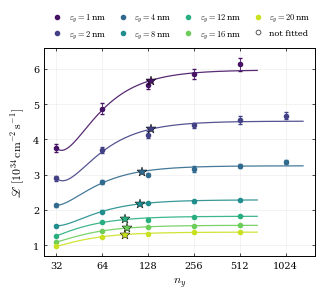

In [17]:
# ── L vs n_y along the single-formula n_m locus ───────────────────────────────
#    Same construction and formatting as the L vs n_m figure: one filled circle
#    series per eps_y (viridis), a Richardson fit whose order k is set by AICc,
#    a star at the fitted n_y^req, and a two-column frameless legend in the
#    lower right. eps_y with too few n_y on the locus to fit are not drawn.
from pathlib import Path
import matplotlib.ticker as mticker

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

prl_style_local = {
    'font.family':      'serif',
    'font.size':        8,
    'axes.labelsize':   8.5,
    'axes.titlesize':   8,
    'legend.fontsize':  6.5,
    'xtick.labelsize':  7,
    'ytick.labelsize':  7,
    'axes.linewidth':   0.7,
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linewidth':   0.4,
    'lines.linewidth':  1.0,
    'lines.markersize': 3.2,
    'text.usetex':      False,
    'mathtext.fontset': 'cm',
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
}

EPS_SHOW_NY = list(EPS_FIT)   # fitted emittances only; unfitted ones not drawn
NY_TICKS    = [32, 64, 128, 256, 512, 1024, 2048]

with plt.rc_context(prl_style_local):
    fig, ax = plt.subplots(figsize=(3.5, 2.7))
    colors = plt.cm.viridis(np.linspace(0.05, 0.92, len(EPS_SHOW_NY)))

    for eps_nm, color in zip(EPS_SHOW_NY, colors):
        g   = SW[eps_nm]
        aw  = NY_WINDOW[eps_nm]
        gw  = aw['window']                       # points actually fitted
        gx  = g[~g['n_y'].isin(gw['n_y'])]       # below the asymptotic window

        # fit — Richardson of AIC-selected order k, on the asymptotic window
        fit   = FIT_NY[eps_nm]
        beta  = fit['beta']
        k_e   = K_SEL_NY[eps_nm]
        ns_e  = NY_SCALE[eps_nm]
        ny_rq = NY_REQ[eps_nm]
        top   = max(g['n_y'].max(), ny_rq if np.isfinite(ny_rq) else 0) * 1.3
        # curve spans the FITTED window only — extrapolating it back through the
        # excluded points would redraw the artefact the window exists to remove.
        nn    = np.geomspace(gw['n_y'].min(), top, 250)
        Lfit  = (beta[0] - sum(beta[i] / (nn / ns_e)**(P_NY * i)
                               for i in range(1, k_e + 1))) / L_UNIT
        ok    = Lfit > 0
        ax.plot(nn[ok], Lfit[ok], '-', color=color, lw=0.9, alpha=0.9, zorder=4)
        if np.isfinite(ny_rq) and ny_rq > 0:
            L_at_req = (beta[0] - sum(beta[i] / (ny_rq / ns_e)**(P_NY * i)
                                      for i in range(1, k_e + 1))) / L_UNIT
            ax.plot([ny_rq], [L_at_req], '*', color=color, ms=7,
                    markeredgecolor='black', markeredgewidth=0.35, zorder=10)

        # fitted points (filled)
        ax.errorbar(gw['n_y'].values, gw['mean_L'].values / L_UNIT,
                    yerr=gw['std_L'].values / L_UNIT,
                    fmt='o', color=color, ecolor=color,
                    capsize=1.2, elinewidth=0.6, lw=0, ms=3.0,
                    zorder=5)
        # points below the asymptotic window: shown, not fitted (open markers)
        if len(gx):
            ax.errorbar(gx['n_y'].values, gx['mean_L'].values / L_UNIT,
                        yerr=gx['std_L'].values / L_UNIT,
                        fmt='o', mfc='none', color=color, ecolor=color,
                        capsize=1.2, elinewidth=0.6, lw=0, ms=3.4,
                        markeredgewidth=0.7, zorder=5)

    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.FixedLocator(NY_TICKS))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter([str(t) for t in NY_TICKS]))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xlabel(r'$n_y$')
    ax.set_ylabel(r'$\mathscr{L}\ [10^{34}\,\mathrm{cm^{-2}\,s^{-1}}]$')
    ax.tick_params(direction='in', length=2.5, width=0.5, top=True, right=True)
    ax.tick_params(which='minor', direction='in', length=1.5, width=0.4,
                   top=True, right=True)
    # compact in-axes legend with eps_y values only
    handles, labels = [], []
    for eps_nm, color in zip(EPS_SHOW_NY, colors):
        handles.append(plt.Line2D([0], [0], marker='o', color=color, lw=0, markersize=3))
        labels.append(fr'$\varepsilon_y={eps_nm:g}\,$nm')
    handles.append(plt.Line2D([0], [0], marker='o', mfc='none', color='0.35',
                             lw=0, markersize=3.4, markeredgewidth=0.7))
    labels.append('not fitted')
    # legend above the axes so it cannot overlap the curves
    ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.02),
              frameon=False, fontsize=6.0, ncol=4, columnspacing=1.0,
              handletextpad=0.4, borderaxespad=0.0)
    save_fig(fig, 'L_vs_ny')
    plt.show()

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved: plots/ny_req_tuning.pdf, plots/ny_req_tuning.png


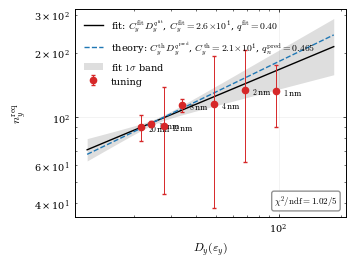


  fitted q = 0.402 +/- 0.152     C_y = 26.16     chi2/ndf = 1.02/5
  q = 0.215 :  chi2/ndf = 1.20/6   p = 0.977   -> hypothesis consistent over D_y = 21.5-97.4


In [18]:
# ── n_y^req vs D_y — the test of n_y^req ∝ D_y^q_n, q_n = q_p + 1/4 (Q_NY) ──
#    Same construction and formatting as the n_m^req/(n_x n_y n_z) vs D_y figure.
with plt.rc_context(prl_style_local):
    fig, ax = plt.subplots(figsize=(3.5, 2.7))

    import math as _math
    def _stdform(x):
        if not (x and _math.isfinite(x)): return ('0', 0)
        e = int(_math.floor(_math.log10(abs(x))))
        return (f'{x/10**e:.1f}', e)

    # data
    ax.errorbar(D_FIT, N_FIT, yerr=N_FIT*S_FIT, fmt='o', ms=4.5, color='C3',
                capsize=1.5, ecolor='C3', elinewidth=0.7, lw=0,
                zorder=5, label='tuning')

    dx = np.geomspace(D_FIT.min()*0.55, D_FIT.max()*1.9, 80)

    # power-law line — fitted
    Cy_mant, Cy_exp = _stdform(CY_FIT)
    ax.plot(dx, CY_FIT * dx**Q_FIT, '-', color='k', lw=1.0, zorder=4,
            label=(fr'fit: $C_y^{{\mathrm{{fit}}}}\,D_y^{{q^{{\mathrm{{fit}}}}}}$, '
                   fr'$C_y^{{\mathrm{{fit}}}}={Cy_mant}\!\times\!10^{{{Cy_exp}}}$, '
                   fr'$q^{{\mathrm{{fit}}}}={Q_FIT:.2f}$'))

    # the hypothesis, normalisation fitted to the same points
    ax.plot(dx, CY_HYP * dx**Q_NY, '--', color='C0', lw=1.0, zorder=4,
            label=(fr'theory: $C_y^{{\mathrm{{th}}}}\,D_y^{{q^{{\mathrm{{pred}}}}}}$, '
                   fr'$C_y^{{\mathrm{{th}}}}={_stdform(CY_HYP)[0]}\!\times\!10^{{{_stdform(CY_HYP)[1]}}}$, '
                   fr'$q_n^{{\mathrm{{pred}}}}={Q_NY:.3f}$'))

    # 1-sigma band on the fit line (joint cov of intercept + slope)
    logdx = np.log(dx)
    sig_pred = np.sqrt(np.maximum(VAR_I + 2.0*logdx*COV_QI + (logdx**2)*VAR_Q, 0.0))
    y_c = CY_FIT * dx**Q_FIT
    ax.fill_between(dx, y_c*np.exp(-sig_pred), y_c*np.exp(sig_pred),
                    color='k', alpha=0.13, lw=0, zorder=3,
                    label=fr'fit $1\sigma$ band')

    # chi2/ndf + p-value, bottom right
    # One chi2 only: the goodness of fit of the drawn free power law. The
    # constrained q_n = Q_NY test is a separate hypothesis test, reported in
    # CALIBRATION_RESULTS.md rather than on the figure.
    ax.text(0.97, 0.04,
            fr'$\chi^2/\mathrm{{ndf}} = {CHI2_FREE:.2f}/{NDF_FREE}$',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=6.5, linespacing=1.2,
            bbox=dict(facecolor='white', alpha=0.85,
                      edgecolor='0.5', boxstyle='round,pad=0.25'))

    # per-point eps_y annotation
    for e, D, N in zip(EPS_FIT, D_FIT, N_FIT):
        ax.annotate(fr'${e:g}\,$nm', (D, N), textcoords='offset points',
                    xytext=(5, -3), fontsize=5.6)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$D_y(\varepsilon_y)$')
    ax.set_ylabel(r'$n_y^{\mathrm{req}}$')
    ax.tick_params(direction='in', length=2.5, width=0.5, top=True, right=True)
    ax.tick_params(which='minor', direction='in', length=1.5, width=0.4,
                   top=True, right=True)
    ax.legend(loc='upper left', frameon=False, fontsize=7)

    save_fig(fig, 'ny_req_tuning')
    plt.show()
    print(f'\n  fitted q = {Q_FIT:.3f} +/- {SIG_Q:.3f}     C_y = {CY_FIT:.2f}     '
          f'chi2/ndf = {CHI2_FREE:.2f}/{NDF_FREE}')
    print(f'  q = {Q_PINCH:.3f} :  chi2/ndf = {CHI2_HYP:.2f}/{NDF_HYP}   p = {P_HYP:.3f}   '
          f'-> hypothesis {"consistent" if P_HYP > 0.05 else "disfavoured"} '
          f'over D_y = {D_FIT.min():.1f}-{D_FIT.max():.1f}')

## `κ` vs `D_y` — the constant of the `n_y` law

The single empirical constant of the `n_y` law, `κ = n_y^req/(2c_yR(D_y))`, per emittance. Flat in `D_y` is the test of `R(D_y)`; the cell also writes `data/gp_kappa_export.csv` for the cross-code comparison with WarpX.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


  note: data/wx_kappa_export.csv not found — GP++ points only


Saved: plots/kappa_vs_Dy.pdf, plots/kappa_vs_Dy.png


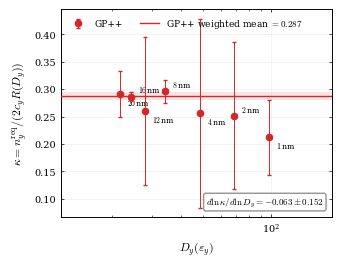


Wrote data/gp_kappa_export.csv  (7 rows)
code  eps_y_nm       D_y  R_pinch    n_y_req  sigma_log  c_y    kappa  sigma_kappa
GP++       1.0 97.364051 4.968002 132.664932   0.322136 20.0 0.212284     0.068384
GP++       2.0 68.752169 4.635573 133.548180   0.534082 20.0 0.251253     0.134189
GP++       4.0 48.520827 4.307962 115.861780   0.671563 20.0 0.256354     0.172158
GP++       8.0 34.215548 3.985424 113.622710   0.071585 20.0 0.295769     0.021173
GP++      12.0 27.878358 3.799186  90.859869   0.515730 20.0 0.260166     0.134176
GP++      16.0 24.100805 3.668170  93.403830   0.029817 20.0 0.286199     0.008534
GP++      20.0 21.522989 3.567196  90.127311   0.142439 20.0 0.291084     0.041462


Wrote data/gp_calibration_export.csv (14 rows) and data/gp_constants_export.csv (11 rows)


In [19]:
# ── kappa vs D_y — is the single empirical constant of the n_y law constant? ──
#    kappa_i = n_y^req_i / (2 c_y R(D_y,i)). A flat kappa supports R(D_y); a
#    kappa drifting with D_y would falsify the size law whatever its mean.
#    WarpX points are overlaid when data/wx_kappa_export.csv is present (that
#    file is produced by the WarpX calibration notebook, same column names as
#    the GP++ export written below).
with plt.rc_context(prl_style_local):
    fig, ax = plt.subplots(figsize=(3.5, 2.7))

    ax.errorbar(D_FIT, KAPPA, yerr=SIG_KAP, fmt='o', ms=4.5, color='C3',
                capsize=1.5, ecolor='C3', elinewidth=0.7, lw=0, zorder=5,
                label='GP++')
    ax.axhline(KAPPA_MEAN, color='C3', ls='-', lw=1.0, zorder=4,
               label=fr'GP++ weighted mean $= {KAPPA_MEAN:.3f}$')
    ax.fill_between([D_FIT.min()*0.55, D_FIT.max()*1.9],
                    KAPPA_MEAN - KAPPA_MEAN_ERR, KAPPA_MEAN + KAPPA_MEAN_ERR,
                    color='C3', alpha=0.13, lw=0, zorder=2)

    WX_KAPPA_CSV = Path('data/wx_kappa_export.csv')
    if WX_KAPPA_CSV.exists():
        _wx = pd.read_csv(WX_KAPPA_CSV)
        _wm = float((_wx['kappa'] / _wx['sigma_log']**2).sum()
                    / (1.0 / _wx['sigma_log']**2).sum())
        ax.errorbar(_wx['D_y'], _wx['kappa'],
                    yerr=_wx['kappa'] * _wx['sigma_log'], fmt='s', ms=4.0,
                    color='C0', capsize=1.5, ecolor='C0', elinewidth=0.7, lw=0,
                    zorder=5, label='WarpX')
        ax.axhline(_wm, color='C0', ls='--', lw=1.0, zorder=4,
                   label=fr'WarpX weighted mean $= {_wm:.3f}$')
    else:
        print(f'  note: {WX_KAPPA_CSV} not found — GP++ points only')

    for j, (e, D, k_) in enumerate(zip(EPS_FIT, D_FIT, KAPPA)):
        ax.annotate(fr'${e:g}\,$nm', (D, k_), textcoords='offset points',
                    xytext=(5, 3 if j % 2 else -8), fontsize=5.6)

    ax.text(0.97, 0.04,
            fr'$d\ln\kappa/d\ln D_y = {KAPPA_SLOPE:+.3f} \pm {KAPPA_SLOPE_ERR:.3f}$',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=6.5,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='0.5',
                      boxstyle='round,pad=0.25'))

    ax.set_xscale('log')
    ax.set_xlim(D_FIT.min()*0.55, D_FIT.max()*1.9)
    ax.set_xlabel(r'$D_y(\varepsilon_y)$')
    ax.set_ylabel(r'$\kappa = n_y^{\mathrm{req}}/(2c_yR(D_y))$')
    ax.tick_params(direction='in', length=2.5, width=0.5, top=True, right=True)
    ax.tick_params(which='minor', direction='in', length=1.5, width=0.4,
                   top=True, right=True)
    _h, _l = ax.get_legend_handles_labels()
    _o = sorted(range(len(_l)), key=lambda j: 'mean' in _l[j])
    ax.legend([_h[j] for j in _o], [_l[j] for j in _o],
              loc='upper left', frameon=False, fontsize=6.5, ncol=2)

    save_fig(fig, 'kappa_vs_Dy')
    plt.show()

# ── CSV export for the cross-code (WarpX) comparison ─────────────────────────
KAPPA_EXPORT = pd.DataFrame({
    'code':       'GP++',
    'eps_y_nm':   EPS_FIT,
    'D_y':        D_FIT,
    'R_pinch':    R_FIT,
    'n_y_req':    N_FIT,
    'sigma_log':  S_FIT,
    'c_y':        C_Y_CUT,
    'kappa':      KAPPA,
    'sigma_kappa': SIG_KAP,
})
KAPPA_EXPORT.to_csv('data/gp_kappa_export.csv', index=False)
print(f'\nWrote data/gp_kappa_export.csv  ({len(KAPPA_EXPORT)} rows)')
print(KAPPA_EXPORT.to_string(index=False))

# Full calibration export: both families, the fitted constants, and everything a
# cross-code comparison needs. n_m rows carry n_m^req/(n_x n_y n_z) and the
# measured slope b = s - q; n_y rows carry n_y^req and kappa.
_rows = []
for e, D, R_, N_, S_, k_, sk_ in zip(EPS_FIT, D_FIT, R_FIT, N_FIT, S_FIT, KAPPA, SIG_KAP):
    _rows.append(dict(code='GP++', family='n_y', eps_y_nm=e, D_y=D, R_pinch=R_,
                      value=N_, sigma_log=S_, c_y=C_Y_CUT, kappa=k_,
                      sigma_kappa=sk_))
for _, r in cal_df[cal_df['n_m_req_per_nxyz'].notna()].iterrows():
    _D = float(r['D_y'])
    _rows.append(dict(code='GP++', family='n_m', eps_y_nm=float(r['eps_y_nm']),
                      D_y=_D, R_pinch=R_pinch(_D),
                      value=float(r['n_m_req_per_nxyz']),
                      sigma_log=float(r['sigma_log_nm']), c_y=C_Y_CUT,
                      kappa=np.nan, sigma_kappa=np.nan))
CAL_EXPORT = pd.DataFrame(_rows)
CAL_EXPORT.to_csv('data/gp_calibration_export.csv', index=False)

CONST_EXPORT = pd.DataFrame([
    dict(code='GP++', name='q_pred',  value=Q_PINCH,      error=np.nan,
         note='derived pinch exponent, R = Lambda D^q'),
    dict(code='GP++', name='Lambda',  value=LAMBDA,      error=np.nan,
         note='normalisation of R over D_y in [21.5, 137.8]'),
    dict(code='GP++', name='c_y',     value=C_Y_CUT,     error=np.nan,
         note='vertical cut multiplier, box is +/- c_y sigma_y*'),
    dict(code='GP++', name='q_fit',   value=Q_FIT,       error=SIG_Q,
         note='free power-law slope of n_y^req vs D_y'),
    dict(code='GP++', name='C_y_fit', value=CY_FIT,      error=np.nan,
         note='normalisation of the free n_y fit'),
    dict(code='GP++', name='b_fit',   value=s_param - Q_PINCH, error=sigma_s,
         note='measured slope of n_m^req/(n_x n_y n_z) vs D_y; b = s - q'),
    dict(code='GP++', name='s_fit',   value=s_param,     error=sigma_s,
         note='b_fit + q_pred'),
    dict(code='GP++', name='C_m_fit', value=C_m,         error=sigma_C_m,
         note='normalisation of the n_m fit'),
    dict(code='GP++', name='b_cons',  value=S_CONS - Q_PINCH, error=np.nan,
         note='conservative locus slope used by the runs'),
    dict(code='GP++', name='s_cons',  value=S_CONS,      error=np.nan,
         note='b_cons + q_pred'),
    dict(code='GP++', name='C_m_cons', value=C_M_CONS,   error=np.nan,
         note='conservative locus normalisation'),
])
CONST_EXPORT.to_csv('data/gp_constants_export.csv', index=False)
print(f'Wrote data/gp_calibration_export.csv ({len(CAL_EXPORT)} rows) and '
      f'data/gp_constants_export.csv ({len(CONST_EXPORT)} rows)')


## Figure 5 — Pseudoflat instability across parameter settings

Coefficient of variation (CV) of the seed-averaged luminosity across grid /
time-step settings, as a function of vertical emittance `ε_y`. Reproduced from
`analysis/variance_study.ipynb`. The nominal operating values `n_x = 512`,
`n_y = 512`, and `n_t = 6` are shown in **bold** in the legend.


In [ ]:
# =============================================================================
# Figure 5: Pseudoflat Instability - CV across parameter settings vs eps_y
# Reproduced from analysis/variance_study.ipynb (fig4). The nominal settings
# n_x=512, n_y=512 are bold in the legend. The n_t and n_m series have been
# dropped from this figure (n_m is exported separately, see below).
#
# SELECTION. Each series varies ONE parameter with everything else at nominal.
# The series select on source_dir=='output', which works only because that
# directory happens to hold nominal runs; output_nm mixes n_m, n_t and
# integration_method at the same grid, so do not widen by source dir.
# The tidy data behind this figure -- including the n_m sweep -- is exported by
# analysis/pseudoflat_cv_export.py to data/pseudoflat_cv_{points,curves}.csv.
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- PRL publication style (identical to the source notebook) ----------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'legend.fontsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'text.usetex': False,
    'mathtext.fontset': 'cm',
})

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

# Unicode mathematical-bold digits render bold under the 'cm' mathtext fontset
# (which cannot bold digits via \mathbf), while matching the surrounding font.
_B512 = '\U0001D7D3\U0001D7CF\U0001D7D0'   # bold "512"

# --- Load CSV ----------------------------------------------------------------
df_all = pd.read_csv('data/lumi_extracted.csv')
for c in ['n_x', 'n_y', 'n_z', 'n_m', 'emitt_x', 'emitt_y', 'lumi_ee', 'seed',
          'integration_method', 'n_t', 'cut_x', 'cut_y', 'cut_z', 'offset_y']:
    df_all[c] = pd.to_numeric(df_all[c], errors='coerce')
df_all = df_all.dropna(subset=['lumi_ee']).copy()

ey_cap = 0.008  # 8 nm cap

def cv_across_settings(sub_df, param_key):
    """CV(%) of seed-averaged luminosity across parameter settings at each eps_y."""
    grp = sub_df.groupby([param_key, 'emitt_y'])['lumi_ee'].mean().reset_index()
    result = []
    for ey, block in grp.groupby('emitt_y'):
        means = block['lumi_ee'].values
        if len(means) >= 2:
            mu = means.mean()
            if mu > 0:
                result.append((round(ey * 1000, 4),
                               np.std(means, ddof=1) / mu * 100.0))
    return sorted(result)

# 1. nx variation: output dir, ex=0.9, ny=512, nz=25, ey <= 8nm
recs_nx = df_all[
    (df_all['source_dir'] == 'output') & (df_all['emitt_x'] == 0.9) &
    (df_all['n_y'] == 512) & (df_all['n_z'] == 25) &
    (df_all['offset_y'] == 0) & (df_all['emitt_y'] <= ey_cap)]
cv_nx = cv_across_settings(recs_nx, 'n_x')
print(f"nx: {len(cv_nx)} ey points, settings = {sorted(recs_nx['n_x'].unique())}")

# 2. ny variation: output dir, ex=0.9, nx=512, nz=25, ey <= 8nm
recs_ny = df_all[
    (df_all['source_dir'] == 'output') & (df_all['emitt_x'] == 0.9) &
    (df_all['n_x'] == 512) & (df_all['n_z'] == 25) &
    (df_all['offset_y'] == 0) & (df_all['emitt_y'] <= ey_cap)]
cv_ny = cv_across_settings(recs_ny, 'n_y')
print(f"ny: {len(cv_ny)} ey points, settings = {sorted(recs_ny['n_y'].unique())}")

# --- Plot (PRL single-column: 3.375 in) --------------------------------------
fig, ax = plt.subplots(figsize=(3.375, 2.8))

styles = [
    (cv_nx, r'$n_x \in \{128, 256, ' + _B512 + r', 1024\}$',
     '#1f77b4', 'o', '-'),
    (cv_ny, r'$n_y \in \{128, 256, ' + _B512 + r', 1024\}$',
     '#d62728', 's', '-'),
]

for pts, lbl, col, mk, ls in styles:
    if pts:
        xs, ys = zip(*pts)
        ax.plot(xs, ys, color=col, marker=mk, ls=ls, label=lbl)

ax.set_xlabel(r'$\varepsilon_y$ (nm)')
ax.set_ylabel(r'CV of $\bar{\mathscr{L}}$ across settings (%)')
ax.legend(loc='upper right', framealpha=0.9)
ax.minorticks_on()
ax.set_xlim(0, 8.5)
ax.set_ylim(bottom=0)
fig.tight_layout()

for ext in ('pdf', 'png'):
    out = PLOT_DIR / f'fig4_pseudoflat_instability_all_params.{ext}'
    fig.savefig(out, bbox_inches='tight', dpi=300)
    print(f'Saved: {out}')
plt.show()


## Figure 6 — 3D luminosity variance mesh

Mean luminosity surface over the `(ε_x, ε_y)` emittance grid, with per-point
min–max error bars split at the mean. Reproduced unchanged from
`analysis/documenting_variance_fig_1.ipynb`.


Saved: plots/variance_3d_lumi_mesh.pdf


Saved: plots/variance_3d_lumi_mesh.png


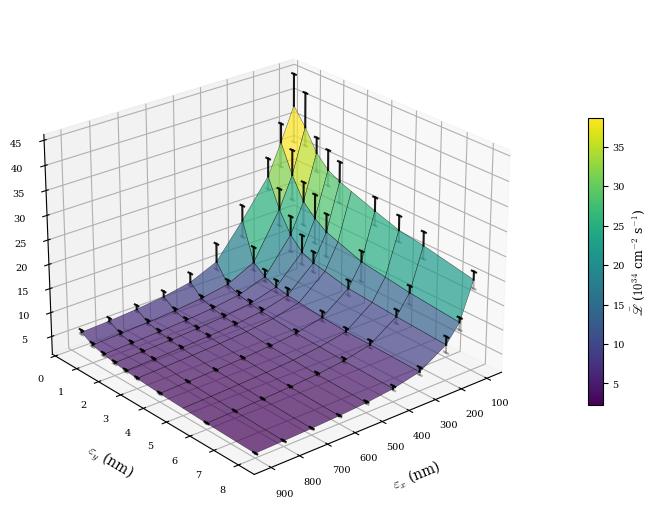

In [22]:
# =============================================================================
# Figure 6: 3D luminosity variance mesh over (eps_x, eps_y)
# Reproduced unchanged from analysis/documenting_variance_fig_1.ipynb.
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata
from pathlib import Path

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

def lumi_to_rate(L_cm2s):
    """`lumi_ee` is already a rate in cm^-2 s^-1 (converted at extraction from
    GP++'s per-crossing m^-2 with the .ref's own f_rep, n_b); scale to 1e34."""
    return L_cm2s / 1e34

# --- Load and select the anchor configuration --------------------------------
df = pd.read_csv('data/lumi_extracted.csv')
# Template defaults: n_m=100000, n_t=6, integration_method=2. NaN -> default.
mask = (
    (df['n_x'] == 512) & (df['n_y'] == 512) & (df['n_z'] == 25) &
    (df['offset_y'] == 0) &
    (df['particles'] == 0.624) &
    (df['beta_x'] == 12.0) & (df['beta_y'] == 0.12) &
    (df['sigma_z'] == 100) &
    ((df['integration_method'] == 2) | df['integration_method'].isna()) &
    ((df['n_t'] == 6) | df['n_t'].isna()) &
    ((df['n_m'] == 100000) | df['n_m'].isna()) &
    (df['emitt_x'].isin([0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]))
)
sub = df[mask].copy()
sub['emitx_nm'] = sub['emitt_x'] * 1000
sub['emity_nm'] = sub['emitt_y'] * 1000
sub = sub[sub['emity_nm'] <= 8]
sub['lumi_rate'] = lumi_to_rate(sub['lumi_ee'])

# Deduplicate per (emitx, emity, seed); cap at 15 unique seeds per point.
sub = sub.sort_values('source_dir').drop_duplicates(
    subset=['emitx_nm', 'emity_nm', 'seed'], keep='first')
MAX_SEEDS = 15
sub = (sub
    .sort_values(['emitx_nm', 'emity_nm', 'seed'])
    .groupby(['emitx_nm', 'emity_nm'], as_index=False)
    .head(MAX_SEEDS))

# --- Style (identical to the source notebook) --------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 10,
    'text.usetex': False,
    'mathtext.fontset': 'cm',
})

# Aggregate
agg = sub.groupby(['emitx_nm', 'emity_nm'])['lumi_rate'].agg(
    ['mean', 'min', 'max']).reset_index()

ex_vals = sorted(agg['emitx_nm'].unique())
ey_vals = sorted(agg['emity_nm'].unique())

# Build 2D grids - interpolate missing points so panels connect
EX, EY = np.meshgrid(ex_vals, ey_vals, indexing='ij')
points = agg[['emitx_nm', 'emity_nm']].values
Z_mean = griddata(points, agg['mean'].values, (EX, EY), method='linear')

fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111, projection='3d')

# Coloured surface panels (facecolors mapped to luminosity)
norm = plt.Normalize(np.nanmin(Z_mean), np.nanmax(Z_mean))
fcolors = cm.viridis(norm(Z_mean))
surf = ax.plot_surface(EX, EY, Z_mean, facecolors=fcolors,
                       alpha=0.7, shade=False, edgecolor='k',
                       linewidth=0.3)

# Colourbar
mappable = cm.ScalarMappable(norm=norm, cmap='viridis')
mappable.set_array(Z_mean)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.55, pad=0.1)
cbar.set_label(r'$\bar{\mathscr{L}}$ ($10^{34}$ cm$^{-2}$ s$^{-1}$)', fontsize=9)

# Error bars with serifs - split at the mean:
#   above surface (mean to max): bold and opaque
#   below surface (min to mean): translucent
serif_w_y = 0.08
for _, row in agg.iterrows():
    ex, ey = row['emitx_nm'], row['emity_nm']
    lo, hi, mid = row['min'], row['max'], row['mean']

    ax.plot([ex, ex], [ey, ey], [mid, hi],
           color='k', linewidth=1.5, alpha=0.9, zorder=10)
    ax.plot([ex, ex], [ey - serif_w_y, ey + serif_w_y], [hi, hi],
           color='k', linewidth=1.5, alpha=0.9, zorder=10)

    ax.plot([ex, ex], [ey, ey], [lo, mid],
           color='k', linewidth=1.5, alpha=0.3, zorder=1)
    ax.plot([ex, ex], [ey - serif_w_y, ey + serif_w_y], [lo, lo],
           color='k', linewidth=1.5, alpha=0.3, zorder=1)

ax.set_xlabel(r'$\varepsilon_x$ (nm)', labelpad=8)
ax.set_ylabel(r'$\varepsilon_y$ (nm)', labelpad=8)
ax.set_zlabel(r'$\bar{\mathscr{L}}$ ($10^{34}$ cm$^{-2}$ s$^{-1}$)', labelpad=8)

ax.invert_xaxis()
ax.invert_yaxis()
ax.view_init(elev=25, azim=-130)

fig.tight_layout()
for ext in ('pdf', 'png'):
    out = PLOT_DIR / f'variance_3d_lumi_mesh.{ext}'
    fig.savefig(out, bbox_inches='tight', dpi=300)
    print(f'Saved: {out}')
plt.show()


## Figure 7 — Luminosity gain vs BIB cost (PRL)

Tradeoff between luminosity gain and beam-induced-background (BIB) cost at the
Nominal-m2 operating point, reproduced from `analysis/lumi_bib_plot.ipynb`.
Two emittance sweeps share the baseline `(ε_x = 900 nm, ε_y = 20 nm)`; the
y-axis is the normalized luminosity gain divided by the normalized BIB cost,
with unity marking a break-even tradeoff.

The per-seed BIB reachability counts (`N_BIB`, derived from the raw `pair.dat`
files in the original analysis) are read from the pre-computed cache
`data/lumi_bib_per_seed_cache.csv`, so this cell needs no raw simulation data.


Baseline  L_0 = 1.368 x10^34 cm^-2 s^-1   N_BIB_0 = 44.40
Plotting 10 pts on Curve A, 9 pts on Curve B


Saved: plots/lumi_bib_tradeoff_PRL.pdf


Saved: plots/lumi_bib_tradeoff_PRL.png


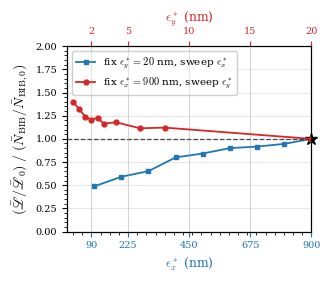

In [23]:
# =============================================================================
# Figure 7: Luminosity gain vs BIB cost at Nominal-m2 (PRL single-column)
# Reproduced from analysis/lumi_bib_plot.ipynb (cells 5, 7, 9, 11, 13, 17).
# N_BIB reachability counts are served from the cached per-seed table instead of
# re-scanning raw pair.dat files, so no raw simulation data is required.
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

def lumi_to_rate(L_cm2s):
    """`lumi_ee` is already a rate in cm^-2 s^-1 (converted at extraction from
    GP++'s per-crossing m^-2 with the .ref's own f_rep, n_b); scale to 1e34."""
    return L_cm2s / 1e34

# --- Load CSV and apply the strict Nominal-m2 filter -------------------------
df = pd.read_csv('data/lumi_extracted.csv')
mask = (
    (df['n_x'] == 512) & (df['n_y'] == 512) & (df['n_z'] == 25) &
    (df['offset_y'] == 0) &
    (df['particles'] == 0.624) &
    (df['beta_x'] == 12.0) & (df['beta_y'] == 0.12) & (df['sigma_z'] == 100) &
    ((df['integration_method'] == 2) | df['integration_method'].isna()) &
    ((df['n_t'] == 6) | df['n_t'].isna()) &
    ((df['n_m'] == 100000) | df['n_m'].isna()) &
    (df['emitt_x'].isin([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]))
)
sub = df[mask].copy()
sub['emitx_nm'] = sub['emitt_x'] * 1000
sub['emity_nm'] = sub['emitt_y'] * 1000
sub = sub[sub['emity_nm'] <= 20]
sub['lumi_rate'] = lumi_to_rate(sub['lumi_ee'])

# Prefer source_dir=='output' (short-form pair dumps), then dedup + 15-seed cap.
src_rank = {'output': 0, 'output_nm': 1, 'output_no_pairs': 2}
sub['src_rank'] = sub['source_dir'].map(src_rank).fillna(3)
sub = sub.sort_values(['emitx_nm', 'emity_nm', 'seed', 'src_rank'])
sub = sub.drop_duplicates(subset=['emitx_nm', 'emity_nm', 'seed'], keep='first')
sub = (sub.sort_values(['emitx_nm', 'emity_nm', 'seed'])
          .groupby(['emitx_nm', 'emity_nm'], as_index=False).head(15))

# --- N_BIB reachability from the cached per-seed table (no raw pair.dat) ------
reach = pd.read_csv('data/lumi_bib_per_seed_cache.csv')
sub_w_reach = sub.merge(reach[['filename', 'source_dir', 'n_reach', 'n_total']],
                        on=['filename', 'source_dir'], how='left')

# --- Aggregate per (eps_x, eps_y) --------------------------------------------
agg = (sub_w_reach.groupby(['emitx_nm', 'emity_nm'], as_index=False)
       .agg(n_seeds=('seed', 'nunique'),
            mean_L=('lumi_rate', 'mean'),
            mean_N_BIB=('n_reach', 'mean'),
            n_reach_count=('n_reach', lambda s: s.notna().sum())))

# --- Baseline and the two curves ---------------------------------------------
BASELINE_EX, BASELINE_EY = 900.0, 20.0
base_row = agg[(agg['emitx_nm'] == BASELINE_EX) & (agg['emity_nm'] == BASELINE_EY)]
if base_row.empty:
    raise RuntimeError('Baseline (900 nm, 20 nm) missing from aggregates.')
L0 = float(base_row['mean_L'].iloc[0])
N0 = float(base_row['mean_N_BIB'].iloc[0])
print(f'Baseline  L_0 = {L0:.3f} x10^34 cm^-2 s^-1   N_BIB_0 = {N0:.2f}')

CURVE_A_EY = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 6.0, 8.0, BASELINE_EY]
CURVE_B_EX = [100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0]

def pull(ex_nm, ey_nm):
    hit = agg[(agg['emitx_nm'] == ex_nm) & (agg['emity_nm'] == ey_nm)]
    if hit.empty:
        return None
    r = hit.iloc[0]
    return dict(mean_L=float(r['mean_L']), mean_N_BIB=float(r['mean_N_BIB']))

def ratio(d):
    if d is None or not np.isfinite(d['mean_N_BIB']) or d['mean_N_BIB'] == 0 \
       or not np.isfinite(d['mean_L']):
        return np.nan
    return (d['mean_L'] / L0) / (d['mean_N_BIB'] / N0)

curve_A = [(ey, pull(BASELINE_EX, ey)) for ey in CURVE_A_EY]
curve_B = [(ex, pull(ex, BASELINE_EY)) for ex in CURVE_B_EX]

A_eys  = np.array([ey for ey, d in curve_A if d is not None and np.isfinite(ratio(d))])
A_rats = np.array([ratio(d) for ey, d in curve_A if d is not None and np.isfinite(ratio(d))])
B_exs  = np.array([ex for ex, d in curve_B if d is not None and np.isfinite(ratio(d))])
B_rats = np.array([ratio(d) for ex, d in curve_B if d is not None and np.isfinite(ratio(d))])
print(f'Plotting {len(A_eys)} pts on Curve A, {len(B_exs)} pts on Curve B')

# --- PRL-style plot (single-column, 3.375 in) --------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'legend.fontsize': 7.5,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.3,
    'text.usetex': False,
    'mathtext.fontset': 'cm',
})

C_B = '#1f77b4'  # blue - eps_x sweep
C_A = '#d62728'  # red  - eps_y sweep

fig, ax = plt.subplots(figsize=(3.375, 2.9))

# Curve B (bottom x-axis) - eps_y fixed at 20 nm, sweep eps_x
lineB, = ax.plot(B_exs, B_rats, 's-', color=C_B, markersize=3.5,
                 linewidth=1.3, label=r'fix $\epsilon_y^*=20$ nm, sweep $\epsilon_x^*$')
ax.set_xlabel(r'$\epsilon_x^*$ (nm)', color=C_B, fontsize=9)
ax.tick_params(axis='x', colors=C_B)

# Curve A (top x-axis) - eps_x fixed at 900 nm, sweep eps_y
ax2 = ax.twiny()
lineA, = ax2.plot(A_eys, A_rats, 'o-', color=C_A, markersize=3.5,
                  linewidth=1.3, label=r'fix $\epsilon_x^*=900$ nm, sweep $\epsilon_y^*$')
ax2.set_xlabel(r'$\epsilon_y^*$ (nm)', color=C_A, fontsize=9)
ax2.tick_params(axis='x', colors=C_A)

# Align both axes so the baseline sits at the right edge (factor=1)
ax.set_xlim(0, BASELINE_EX)
ax2.set_xlim(0, BASELINE_EY)
fracs = [0.1, 0.25, 0.5, 0.75, 1.0]
ax.set_xticks([BASELINE_EX * f for f in fracs])
ax2.set_xticks([BASELINE_EY * f for f in fracs])

ax.set_ylabel(r'$(\bar{\mathscr{L}}/\bar{\mathscr{L}}_0) \; / \; (\bar{N}_\mathrm{BIB}/\bar{N}_{\mathrm{BIB},0})$',
              fontsize=10)
ymax = max(2.0, 1.15 * max(np.nanmax(A_rats) if A_rats.size else 1,
                           np.nanmax(B_rats) if B_rats.size else 1))
ax.set_ylim(0, ymax)

ax.axhline(1.0, color='black', linestyle='--', linewidth=0.9, alpha=0.7)
ax.plot([BASELINE_EX], [1.0], marker='*', color='black',
        markersize=9, zorder=5, clip_on=False)
ax.legend([lineB, lineA], [lineB.get_label(), lineA.get_label()],
          loc='upper left', framealpha=0.92, handlelength=1.8, borderpad=0.4)
ax.minorticks_on()

fig.tight_layout()
for ext in ('pdf', 'png'):
    out = PLOT_DIR / f'lumi_bib_tradeoff_PRL.{ext}'
    fig.savefig(out, bbox_inches='tight', dpi=300)
    print(f'Saved: {out}')
plt.show()
